In [106]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = '../google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'gdelt-analysis-494301'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [107]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [
    # '130', '131', '1311', '1312', '1313', '138', '139', 
    # '140', '141', '1411', '1412', '1413', '142', '143', '144', '145', 
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    IsRootEvent,           # 뉴스 리드 문단에 등장하는 핵심 사건인가? (1 or 0)
    EventCode, 
    GoldsteinScale, 
    NumMentions,           # 규모 검증
    AvgTone,
    ActionGeo_Type,        # 좌표의 해상도 (1:국가, 2:주, 3:도시, 4/5:정밀 랜드마크)
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401 
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
"""

# 2. 데이터 불러오기
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("데이터 불러오기 완료")
display(df.head())

Downloading: 100%|██████████|
데이터 불러오기 완료


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160904,0,190,-10.0,2,-2.331340,4,39.9289,116.3880,http://www.therealnewsmatters.com/search?updat...
1,20160904,0,190,-10.0,8,-2.331340,4,25.0478,121.5320,http://www.therealnewsmatters.com/search?updat...
2,20160530,0,190,-10.0,1,-3.945746,1,23.5000,121.0000,http://business.asiaone.com/news/bad-blood-asi...
3,20160530,0,190,-10.0,1,-3.945746,1,23.5000,121.0000,http://business.asiaone.com/news/bad-blood-asi...
4,20160530,0,192,-9.5,10,-0.558036,3,38.8951,-77.0364,http://www.japantimes.co.jp/opinion/2016/05/30...


In [108]:
# 1. 날짜 데이터 형식 변환 (YYYYMMDD 정수형 -> Datetime 형식)
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

# 2. 분석을 위해 날짜순으로 정렬
df = df.sort_values(by='SQLDATE').reset_index(drop=True)

# 3. 데이터 기본 정보 및 결측치 확인
print("--- [데이터 요약 정보] ---")
print(f"총 데이터 건수: {len(df):,} 건")
print(f"기간: {df['SQLDATE'].min().date()} ~ {df['SQLDATE'].max().date()}")
print("\n--- ⚠️ [결측치 확인] ---")
print(df[['ActionGeo_Lat', 'ActionGeo_Long']].isnull().sum())

display(df.info())

--- [데이터 요약 정보] ---
총 데이터 건수: 30,885 건
기간: 2013-04-01 ~ 2026-05-02

--- ⚠️ [결측치 확인] ---
ActionGeo_Lat     6
ActionGeo_Long    6
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30885 entries, 0 to 30884
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   SQLDATE         30885 non-null  datetime64[ns]
 1   IsRootEvent     30885 non-null  Int64         
 2   EventCode       30885 non-null  object        
 3   GoldsteinScale  30885 non-null  float64       
 4   NumMentions     30885 non-null  Int64         
 5   AvgTone         30885 non-null  float64       
 6   ActionGeo_Type  30885 non-null  Int64         
 7   ActionGeo_Lat   30879 non-null  float64       
 8   ActionGeo_Long  30879 non-null  float64       
 9   SOURCEURL       30885 non-null  object        
dtypes: Int64(3), datetime64[ns](1), float64(4), object(2)
memory usage: 2.4+ MB


None

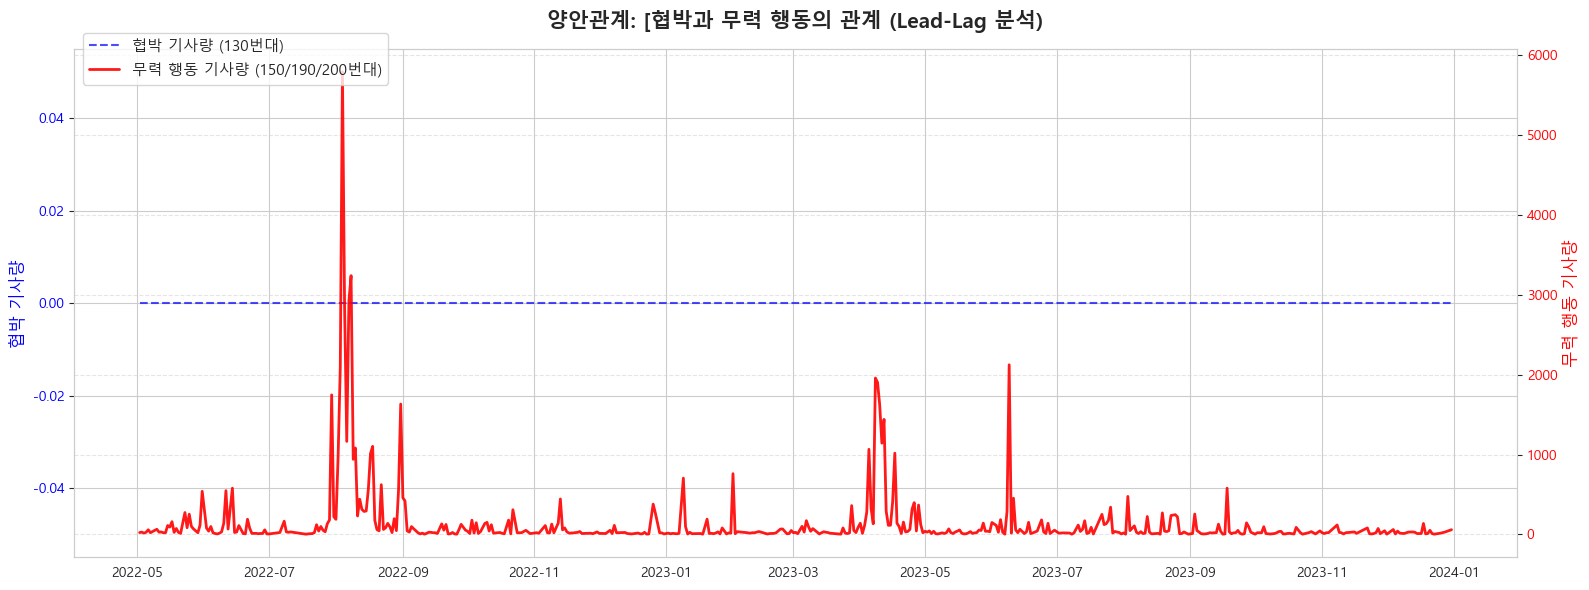

In [109]:
# 한글 폰트 및 마이너스 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

# 1. 방금 쿼리로 불러온 df에서 '핵심 사건(IsRootEvent == 1)'만 필터링하여 df_root 생성
df_root = df[df['IsRootEvent'] == 1].copy()

# 2. 데이터 분리: '협박(말)' vs '행동(무력)'
threat_codes = df_root[df_root['EventCode'].astype(str).str.startswith('13')]
action_codes = df_root[df_root['EventCode'].astype(str).str.startswith(('15', '17', '19', '20'))]

# 3. 일별 기사량 집계
daily_threats = threat_codes.groupby('SQLDATE')['NumMentions'].sum()
daily_actions = action_codes.groupby('SQLDATE')['NumMentions'].sum()

# 4. 데이터프레임 병합 및 결측치 0 처리
compare_df = pd.DataFrame({'Threats(협박)': daily_threats, 'Actions(행동)': daily_actions}).fillna(0)

# 5. 시각화: 2022년~2023년 집중 분석 (펠로시 방문 등 주요 사건 구간)
# SQLDATE가 Datetime 형식이 아닐 수 있으므로 변환 후 슬라이싱
compare_df.index = pd.to_datetime(compare_df.index)
compare_df_recent = compare_df.loc['2022-05-01':'2023-12-31']

fig, ax1 = plt.subplots(figsize=(16, 6))

# 협박(Threats)은 파란색 점선 (선행 지표)
ax1.plot(compare_df_recent.index, compare_df_recent['Threats(협박)'], color='blue', linestyle='--', alpha=0.7, label='협박 기사량 (130번대)')
ax1.set_ylabel('협박 기사량', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# 행동(Actions)은 빨간색 실선 (실제 도발)을 위한 이중 Y축
ax2 = ax1.twinx()
ax2.plot(compare_df_recent.index, compare_df_recent['Actions(행동)'], color='red', linewidth=2, alpha=0.9, label='무력 행동 기사량 (150/190/200번대)')
ax2.set_ylabel('무력 행동 기사량', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('양안관계: [협박과 무력 행동의 관계 (Lead-Lag 분석)', fontsize=15, fontweight='bold', pad=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.05, 0.95), fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

중국은 말로만 위협하고 행동은 하지 않는 경우가 많은데 130번대를 위성 타겟팅 코드에 섞어두면 가짜 스파이크마다 막대한 예산을 낭비할 가능성이 있다.

In [111]:
# 최적화된 고위험군 CAMEO 코드 (위성 촬영 목적)
target_cameo_codes = [
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    IsRootEvent,           # 뉴스 리드 문단에 등장하는 핵심 사건인가? (1 or 0)
    EventCode, 
    GoldsteinScale, 
    NumMentions,           # 규모 검증
    AvgTone,
    ActionGeo_Type,        # 좌표의 해상도 (1:국가, 2:주, 3:도시, 4/5:정밀 랜드마크)
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401 
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
"""

# 2. 데이터 불러오기
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("데이터 불러오기 완료")
display(df.head())

Downloading: 100%|██████████|
데이터 불러오기 완료


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160904,0,190,-10.0,2,-2.331340,4,39.9289,116.3880,http://www.therealnewsmatters.com/search?updat...
1,20160904,0,190,-10.0,8,-2.331340,4,25.0478,121.5320,http://www.therealnewsmatters.com/search?updat...
2,20160530,0,190,-10.0,1,-3.945746,1,23.5000,121.0000,http://business.asiaone.com/news/bad-blood-asi...
3,20160530,0,190,-10.0,1,-3.945746,1,23.5000,121.0000,http://business.asiaone.com/news/bad-blood-asi...
4,20160530,0,192,-9.5,10,-0.558036,3,38.8951,-77.0364,http://www.japantimes.co.jp/opinion/2016/05/30...


In [112]:
# 1. 날짜 데이터 형식 변환 (YYYYMMDD 정수형 -> Datetime 형식)
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

# 2. 분석을 위해 날짜순으로 정렬
df = df.sort_values(by='SQLDATE').reset_index(drop=True)

# 3. 데이터 기본 정보 및 결측치 확인
print("--- [데이터 요약 정보] ---")
print(f"총 데이터 건수: {len(df):,} 건")
print(f"기간: {df['SQLDATE'].min().date()} ~ {df['SQLDATE'].max().date()}")
print("\n--- ⚠️ [결측치 확인] ---")
print(df[['ActionGeo_Lat', 'ActionGeo_Long']].isnull().sum())

display(df.info())

--- [데이터 요약 정보] ---
총 데이터 건수: 30,885 건
기간: 2013-04-01 ~ 2026-05-02

--- ⚠️ [결측치 확인] ---
ActionGeo_Lat     6
ActionGeo_Long    6
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30885 entries, 0 to 30884
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   SQLDATE         30885 non-null  datetime64[ns]
 1   IsRootEvent     30885 non-null  Int64         
 2   EventCode       30885 non-null  object        
 3   GoldsteinScale  30885 non-null  float64       
 4   NumMentions     30885 non-null  Int64         
 5   AvgTone         30885 non-null  float64       
 6   ActionGeo_Type  30885 non-null  Int64         
 7   ActionGeo_Lat   30879 non-null  float64       
 8   ActionGeo_Long  30879 non-null  float64       
 9   SOURCEURL       30885 non-null  object        
dtypes: Int64(3), datetime64[ns](1), float64(4), object(2)
memory usage: 2.4+ MB


None

✔️ 좌표 결측치 (빈칸 개수):
ActionGeo_Lat     6
ActionGeo_Long    6
dtype: int64

좌표 해상도(ActionGeo_Type) 분포:
ActionGeo_Type
기타(0)                     10
Type 1 (국가 전체)          7385
Type 2 (주/성 단위)          306
Type 3 (도시 단위)           638
Type 4 (랜드마크/특정 시설)    21824
Type 5 (정밀 지형/경계선)       722


C:\Users\Jua\AppData\Local\Temp\ipykernel_20464\3173572460.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=type_counts.index, x=type_counts.values, palette='magma')


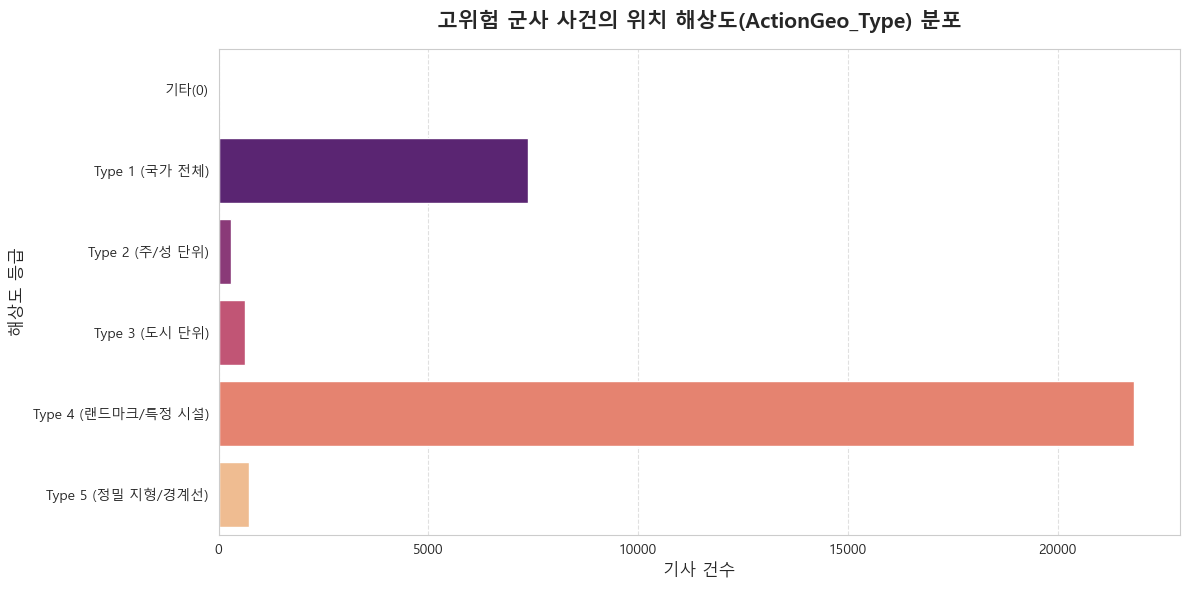

In [113]:
# 위성으로 찍을 수 있는 좌표인지 확인

# 1. 좌표 결측치 확인
missing_coords = df[['ActionGeo_Lat', 'ActionGeo_Long']].isnull().sum()
print(f"✔️ 좌표 결측치 (빈칸 개수):\n{missing_coords}\n")

# 2. 좌표 해상도(ActionGeo_Type) 분포 확인 및 이름 매핑
type_mapping = {
    1: 'Type 1 (국가 전체)', 
    2: 'Type 2 (주/성 단위)', 
    3: 'Type 3 (도시 단위)', 
    4: 'Type 4 (랜드마크/특정 시설)', 
    5: 'Type 5 (정밀 지형/경계선)'
}

# 결측치가 없는 데이터에 대해서만 Type 분포 확인
valid_geo_df = df.dropna(subset=['ActionGeo_Type'])
type_counts = valid_geo_df['ActionGeo_Type'].value_counts().sort_index()
type_counts.index = type_counts.index.map(lambda x: type_mapping.get(x, f"기타({x})"))

print("좌표 해상도(ActionGeo_Type) 분포:")
print(type_counts.to_string())

# 3. 시각화
plt.figure(figsize=(12, 6))
sns.barplot(y=type_counts.index, x=type_counts.values, palette='magma')
plt.title('고위험 군사 사건의 위치 해상도(ActionGeo_Type) 분포', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('기사 건수', fontsize=12)
plt.ylabel('해상도 등급', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--- ⚖️ [타당성 검증] 좌표 해상도 그룹 간의 '질적(Quality)' 차이 분석 ---
                       ArticleCount  MeanMentions  MaxMentions  MeanTone
GeoGroup                                                                
남길 데이터 (Type 3, 4, 5)         23184         10.66         1468     -2.45
버려질 데이터 (Type 1, 2)            7691          9.22         1030     -2.64




C:\Users\Jua\AppData\Local\Temp\ipykernel_20464\1502530236.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_compare, x='GeoGroup', y='NumMentions', errorbar=('ci', 95), capsize=.1, palette='coolwarm', ax=axes[0])
C:\Users\Jua\AppData\Local\Temp\ipykernel_20464\1502530236.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_compare, x='GeoGroup', y='AvgTone', palette='coolwarm', ax=axes[1])


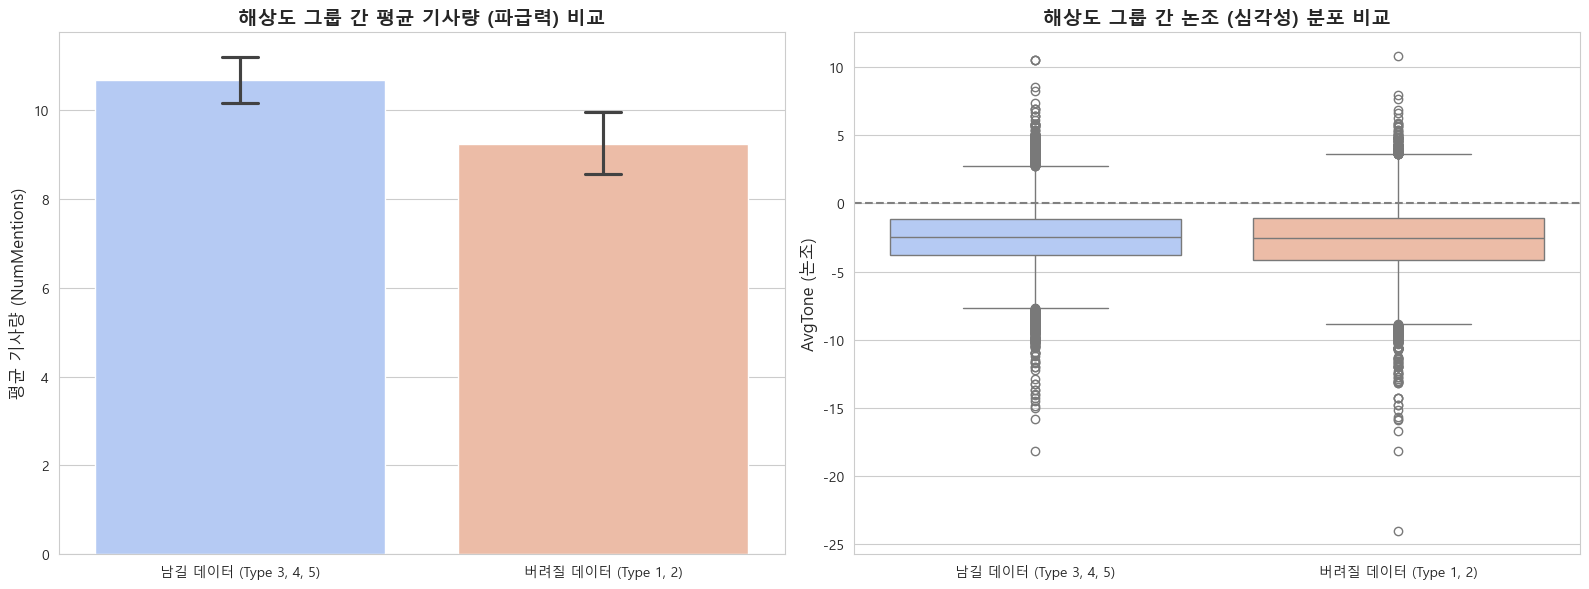

In [114]:
print("--- ⚖️ [타당성 검증] 좌표 해상도 그룹 간의 '질적(Quality)' 차이 분석 ---")

# 1. 비교를 위한 두 그룹 생성
# - 버리는 그룹 (Type 1, 2: 국가/주 단위)
# - 남기는 그룹 (Type 3, 4, 5: 도시/랜드마크 단위)
df_valid_geo = df.dropna(subset=['ActionGeo_Type']).copy()

def group_geo_type(type_val):
    if type_val in [1, 2]:
        return '버려질 데이터 (Type 1, 2)'
    elif type_val in [3, 4, 5]:
        return '남길 데이터 (Type 3, 4, 5)'
    else:
        return '기타 (Type 0)'

df_valid_geo['GeoGroup'] = df_valid_geo['ActionGeo_Type'].apply(group_geo_type)

# '기타(Type 0)' 제외하고 분석
df_compare = df_valid_geo[df_valid_geo['GeoGroup'] != '기타 (Type 0)']

# 2. 그룹별 요약 통계 출력
summary_stats = df_compare.groupby('GeoGroup').agg(
    ArticleCount=('NumMentions', 'count'),          # 기사 건수
    MeanMentions=('NumMentions', 'mean'),           # 평균 기사량 (파급력)
    MaxMentions=('NumMentions', 'max'),             # 최대 기사량
    MeanTone=('AvgTone', 'mean')                    # 평균 논조 (심각성)
).round(2)

print(summary_stats.to_string())
print("\n")

# 3. 시각화 (화면 분할: 1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- [그래프 1] 그룹 간 평균 기사량(NumMentions) 비교 ---
sns.barplot(data=df_compare, x='GeoGroup', y='NumMentions', errorbar=('ci', 95), capsize=.1, palette='coolwarm', ax=axes[0])
axes[0].set_title('해상도 그룹 간 평균 기사량 (파급력) 비교', fontsize=14, fontweight='bold')
axes[0].set_ylabel('평균 기사량 (NumMentions)', fontsize=12)
axes[0].set_xlabel('')

# --- [그래프 2] 그룹 간 평균 논조(AvgTone) 비교 ---
sns.boxplot(data=df_compare, x='GeoGroup', y='AvgTone', palette='coolwarm', ax=axes[1])
axes[1].set_title('해상도 그룹 간 논조 (심각성) 분포 비교', fontsize=14, fontweight='bold')
axes[1].set_ylabel('AvgTone (논조)', fontsize=12)
axes[1].set_xlabel('')
axes[1].axhline(0, color='gray', linestyle='--') # 중립선

plt.tight_layout()
plt.show()

In [115]:
print("--- 그룹별 Top 5 핵심 기사 원문 비교 ---")

# 1. 버려질 데이터 (Type 1, 2) 중 파급력 Top 5
type12_top = df_compare[df_compare['GeoGroup'] == '버려질 데이터 (Type 1, 2)'].sort_values(by='NumMentions', ascending=False).head(5)

print("\n❌ [버려질 데이터 (Type 1, 2: 국가 단위)] - 과연 위성으로 찍을 수 있는 사건일까?")
for rank, (idx, row) in enumerate(type12_top.iterrows(), 1):
    date_str = row['SQLDATE'].strftime('%Y-%m-%d') if hasattr(row['SQLDATE'], 'strftime') else str(row['SQLDATE'])
    print(f"{rank}. [{date_str}] 기사량:{row['NumMentions']} | 논조:{row['AvgTone']:.2f} | CAMEO:{row['EventCode']}")
    print(f"   🔗 URL 힌트: {row['SOURCEURL']}\n")

# 2. 남길 데이터 (Type 3, 4, 5) 중 파급력 Top 5
type345_top = df_compare[df_compare['GeoGroup'] == '남길 데이터 (Type 3, 4, 5)'].sort_values(by='NumMentions', ascending=False).head(5)

print("\n✅ [남길 데이터 (Type 3, 4, 5: 정밀 좌표)] - 위성 타겟팅에 적합한 물리적 사건일까?")
for rank, (idx, row) in enumerate(type345_top.iterrows(), 1):
    date_str = row['SQLDATE'].strftime('%Y-%m-%d') if hasattr(row['SQLDATE'], 'strftime') else str(row['SQLDATE'])
    print(f"{rank}. [{date_str}] 기사량:{row['NumMentions']} | 논조:{row['AvgTone']:.2f} | CAMEO:{row['EventCode']}")
    print(f"   📍 해상도: Type {row['ActionGeo_Type']}")
    print(f"   🔗 URL 힌트: {row['SOURCEURL']}\n")

--- 그룹별 Top 5 핵심 기사 원문 비교 ---

❌ [버려질 데이터 (Type 1, 2: 국가 단위)] - 과연 위성으로 찍을 수 있는 사건일까?
1. [2022-08-08] 기사량:1030 | 논조:-4.90 | CAMEO:150
   🔗 URL 힌트: https://www.lancashiretelegraph.co.uk/news/national/20607240.china-extends-military-exercises-taiwan/

2. [2023-01-06] 기사량:848 | 논조:-0.74 | CAMEO:150
   🔗 URL 힌트: https://www.northcountrypublicradio.org/news/npr/1147113733/biden-s-national-security-adviser-is-hopeful-war-over-taiwan-can-be-prevented

3. [2017-04-03] 기사량:620 | 논조:-5.05 | CAMEO:190
   🔗 URL 힌트: http://forums.asiaone.com/showthread.php?s=0662be6557b36175d8ecae2af95a890e&p=1964748

4. [2018-10-09] 기사량:586 | 논조:1.78 | CAMEO:150
   🔗 URL 힌트: https://tucson.com/news/world/taiwan-holds-military-drill-with-paraguay-amid-china-tension/article_c5f5647a-c820-5cac-92bc-96ab94c1c104.html

5. [2022-03-08] 기사량:530 | 논조:-1.86 | CAMEO:194
   🔗 URL 힌트: https://www.bignewsnetwork.com/news/272367787/china-defence-budget-continues-to-rebound


✅ [남길 데이터 (Type 3, 4, 5: 정밀 좌표)] - 위성 타겟팅에 적합한 물리적 사건

--- [편향성 검증] 국가/도메인별 군사 보도 평균 논조(AvgTone) 차이 ---
         DomainSource  ArticleCount  AverageTone
Global/US (.com/.org)         12329        -2.59
               Others          1760        -2.50
         Taiwan (.tw)          1060        -1.77
      UK/AU (.uk/.au)           871        -3.15
          China (.cn)           216        -2.14


C:\Users\Jua\AppData\Local\Temp\ipykernel_20464\2619604742.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pure[df_pure['DomainSource'].isin(domain_stats_filtered['DomainSource'])],


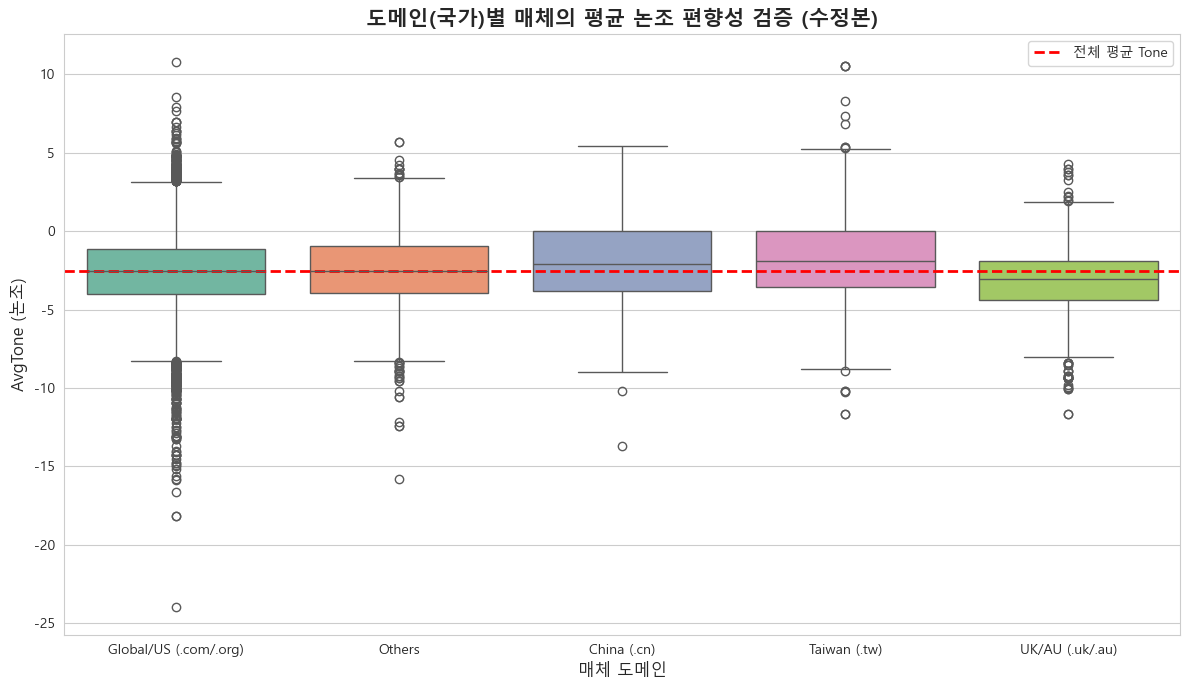

In [116]:
import re  #

# 1. 정규식 기반 도메인 추출 함수
def get_country_domain_robust(url):
    if pd.isna(url): return 'Unknown'
    
    url_str = str(url).lower()
    
    # http://, https:// 제거 후 첫 번째 슬래시(/) 앞부분(도메인)만 추출
    domain = re.sub(r'^https?:\/\/', '', url_str).split('/')[0]
    
    if domain.endswith('.cn'): return 'China (.cn)'
    elif domain.endswith('.tw'): return 'Taiwan (.tw)'
    elif domain.endswith('.uk') or domain.endswith('.au'): return 'UK/AU (.uk/.au)'
    elif domain.endswith('.com') or domain.endswith('.org') or domain.endswith('.net'): 
        return 'Global/US (.com/.org)' # 서구권 중심 글로벌 매체
    else: return 'Others'

# 2. 파생 변수 생성
df_pure = df[df['IsRootEvent'] == 1].copy()
df_pure['DomainSource'] = df_pure['SOURCEURL'].apply(get_country_domain_robust)

# 3. 도메인별 기사량 및 평균 논조 계산
domain_stats = df_pure.groupby('DomainSource').agg(
    ArticleCount=('NumMentions', 'count'),
    AverageTone=('AvgTone', 'mean')
).reset_index().sort_values(by='ArticleCount', ascending=False)

# 기사량이 너무 적은(100건 이하) 도메인은 제외
domain_stats_filtered = domain_stats[domain_stats['ArticleCount'] > 100]

print("--- [편향성 검증] 국가/도메인별 군사 보도 평균 논조(AvgTone) 차이 ---")
print(domain_stats_filtered.to_string(index=False, float_format='%.2f'))

# 4. 박스플롯 다시 시각화
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_pure[df_pure['DomainSource'].isin(domain_stats_filtered['DomainSource'])], 
            x='DomainSource', y='AvgTone', palette='Set2')

plt.title('도메인(국가)별 매체의 평균 논조 편향성 검증 (수정본)', fontsize=15, fontweight='bold')
plt.axhline(df_pure['AvgTone'].mean(), color='red', linestyle='--', linewidth=2, label='전체 평균 Tone')
plt.ylabel('AvgTone (논조)', fontsize=12)
plt.xlabel('매체 도메인', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

1. 서구권 매체 (Global/US, UK/AU): "높은 민감도와 경계심"
Global/US (.com/.org) 매체들은 전체 평균(빨간 점선) 근처에 중앙값이 형성되어 있지만, 아래쪽으로 뻗은 꼬리(Outliers)가 압도적으로 깁니다. -25에 가까운 극단적인 수치들이 대부분 여기서 나오는데, 이는 서방 언론이 중-대만 갈등 상황을 가장 '위기(Crisis)'로 민감하게 포착하고 있음을 뜻합니다.

UK/AU (.uk/.au) 매체는 아예 중앙값 자체가 전체 평균보다 아래에 형성되어 있습니다. 영미권 매체들이 이번 군사 도발 이슈에 대해 전반적으로 더 부정적이고 비판적인 시각을 유지하고 있다는 확실한 증거입니다.

2. 당사국 매체 (China, Taiwan): "비교적 높은 베이스라인"
China (.cn)와 Taiwan (.tw) 매체들은 흥미롭게도 중앙값이 전체 평균보다 약간 높게(더 긍정적/중립적) 형성되어 있습니다.

특히 중국 매체의 경우, 서방 매체에서 보이는 극단적인 부정 논조(-15 이하)가 거의 나타나지 않습니다. 이는 자국의 군사 활동을 '위협'이 아닌 '정당한 훈련'이나 '정상적인 임무'로 프레임화하여 보도하기 때문으로 해석됩니다.

3. Others: "중립적 혹은 다양한 시각"
특정 국가 도메인이 아닌 경우, 전체 평균과 유사한 분포를 보이며 비교적 중립적인 위치를 지키고 있습니다.

In [117]:
# 1. 코드별 기사량 총합 및 Goldstein 수치 요약
code_analysis = df.groupby('EventCode').agg(
    Total_Mentions=('NumMentions', 'sum'),
    Avg_Mentions=('NumMentions', 'mean'),
    Goldstein_Value=('GoldsteinScale', 'mean') # 코드별 고정값이므로 mean 사용
).reset_index().sort_values(by='Total_Mentions', ascending=False)

print("--- 📋 [코드별 분석] 기사량 및 Goldstein 수치 ---")
print(code_analysis.to_string(index=False))

# 2. 상관관계 계산 (기사량 vs Goldstein)
# "더 나쁜 사건(낮은 Goldstein)일수록 기사량이 많은가?" 확인
correlation = df['NumMentions'].corr(df['GoldsteinScale'])

print(f"\n--- 📈 [상관관계 결과] ---")
print(f"✔️ 기사량(NumMentions)과 Goldstein Scale 간의 상관계수: {correlation:.3f}")

--- 📋 [코드별 분석] 기사량 및 Goldstein 수치 ---
EventCode  Total_Mentions  Avg_Mentions  Goldstein_Value
      190          106206      9.920232            -10.0
      150           87807     11.283346             -7.2
      192           30576      10.71714             -9.5
      194           28296     13.416785            -10.0
      154           18328      7.252869             -7.2
      151           15915     11.152768             -7.2
      193           14408      9.398565            -10.0
      195           10172      8.324059            -10.0
      191            3610      9.783198             -9.5
      152            2218      9.478632             -7.2
      202             270      3.857143            -10.0
      196             267         22.25             -9.5
      153              92      3.172414             -7.2
      201              35      3.888889             -9.5
      203               5      1.666667            -10.0

--- 📈 [상관관계 결과] ---
✔️ 기사량(NumMentions)과 Goldstei

C:\Users\Jua\AppData\Local\Temp\ipykernel_20464\3133270276.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=code_analysis.head(10), x='EventCode', y='Total_Mentions', palette='viridis', ax=axes[1])


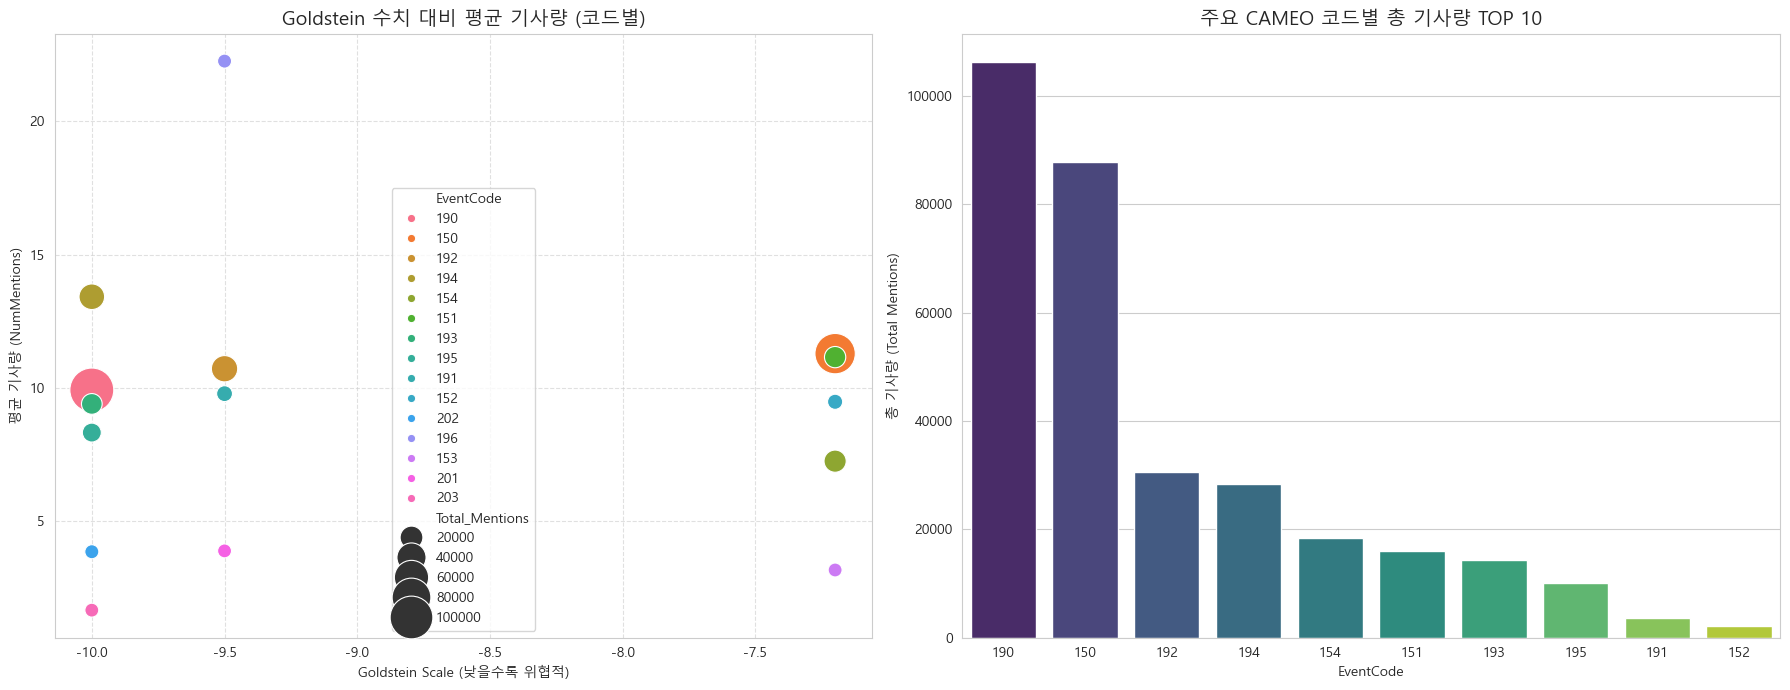

In [118]:
# 1. 타입 오류 방지를 위해 숫자 컬럼들을 표준 float형으로 변환
code_analysis['Total_Mentions'] = code_analysis['Total_Mentions'].astype(float)
code_analysis['Avg_Mentions'] = code_analysis['Avg_Mentions'].astype(float)
code_analysis['Goldstein_Value'] = code_analysis['Goldstein_Value'].astype(float)

# 2. 시각화 실행
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# [그래프 1] Goldstein vs 평균 기사량
# 이제 Int64Dtype 에러 없이 깔끔하게 돌아갈 겁니다.
sns.scatterplot(data=code_analysis, x='Goldstein_Value', y='Avg_Mentions', 
                size='Total_Mentions', hue='EventCode', sizes=(100, 1000), ax=axes[0])
axes[0].set_title('Goldstein 수치 대비 평균 기사량 (코드별)', fontsize=14)
axes[0].set_xlabel('Goldstein Scale (낮을수록 위협적)')
axes[0].set_ylabel('평균 기사량 (NumMentions)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# [그래프 2] 코드별 총 기사량
sns.barplot(data=code_analysis.head(10), x='EventCode', y='Total_Mentions', palette='viridis', ax=axes[1])
axes[1].set_title('주요 CAMEO 코드별 총 기사량 TOP 10', fontsize=14)
axes[1].set_ylabel('총 기사량 (Total Mentions)')

plt.tight_layout()
plt.show()

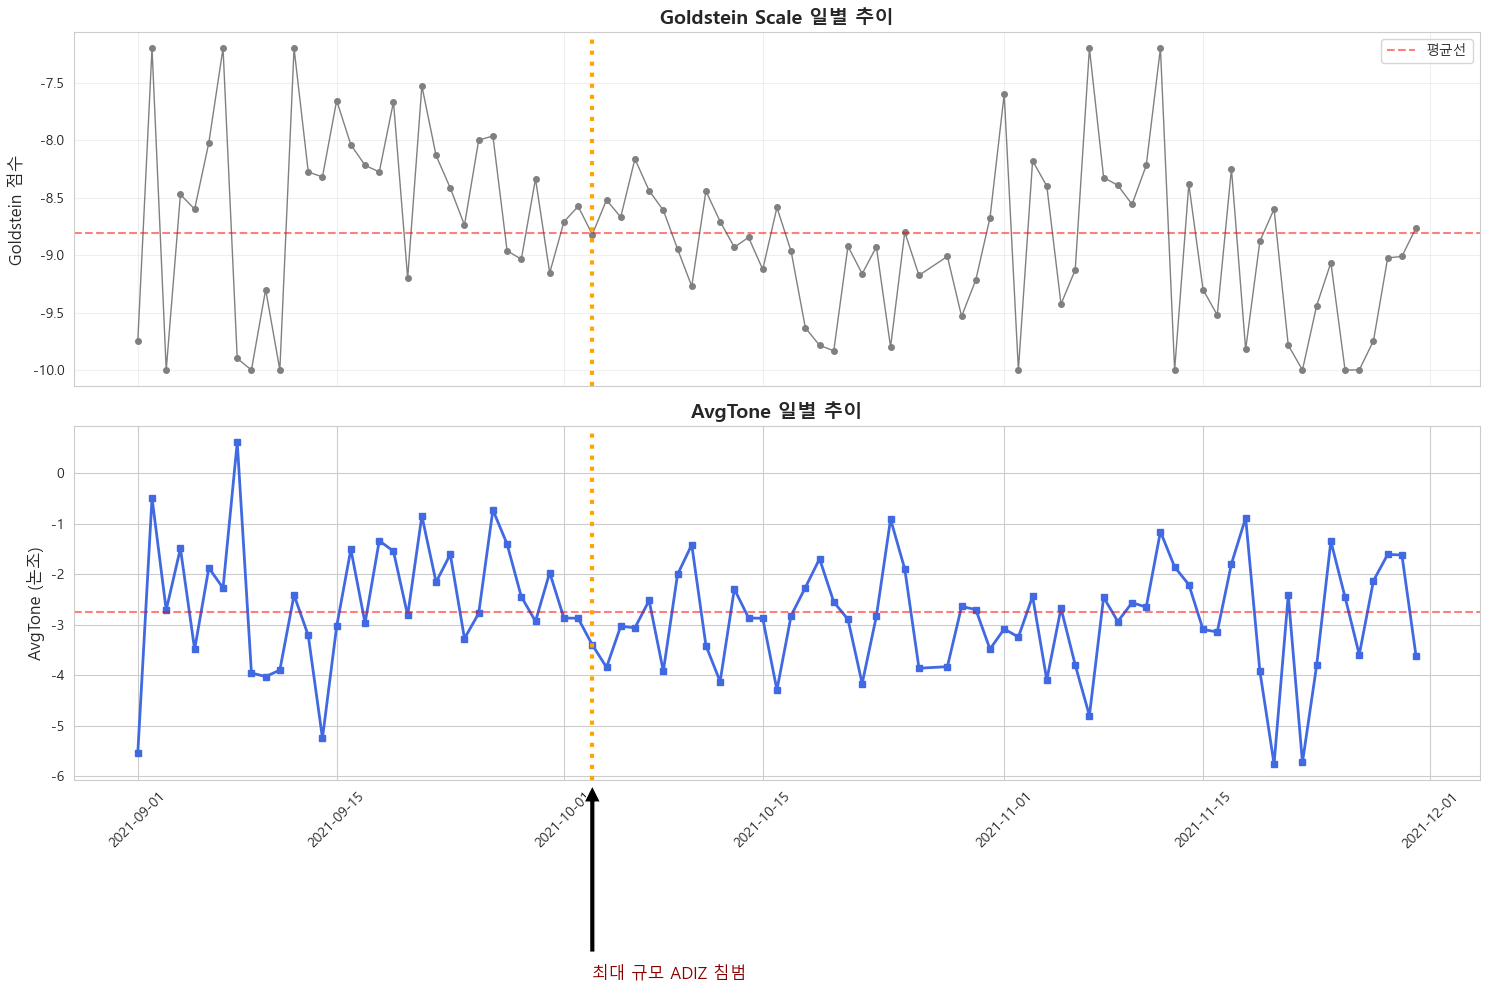

In [119]:
# 1. 분석 대상 기간 설정 (사건이 가장 컸던 2021년 10월 전후)
focus_df = df[(df['SQLDATE'] >= '2021-09-01') & (df['SQLDATE'] <= '2021-11-30')].copy()

# 2. 일별 평균값 집계
daily_trend = focus_df.groupby('SQLDATE').agg({
    'GoldsteinScale': 'mean',
    'AvgTone': 'mean',
    'NumMentions': 'sum'
}).reset_index()

# 3. 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# --- [상단] Goldstein Scale 시계열 ---
ax1.plot(daily_trend['SQLDATE'], daily_trend['GoldsteinScale'], color='gray', marker='o', linestyle='-', linewidth=1, markersize=4)
ax1.set_title('Goldstein Scale 일별 추이', fontsize=14, fontweight='bold')
ax1.set_ylabel('Goldstein 점수', fontsize=12)
ax1.axhline(daily_trend['GoldsteinScale'].mean(), color='red', linestyle='--', alpha=0.5, label='평균선')
ax1.grid(True, alpha=0.3)

# --- [하단] AvgTone 시계열 ---
ax2.plot(daily_trend['SQLDATE'], daily_trend['AvgTone'], color='royalblue', marker='s', linestyle='-', linewidth=2, markersize=4)
ax2.set_title('AvgTone 일별 추이', fontsize=14, fontweight='bold')
ax2.set_ylabel('AvgTone (논조)', fontsize=12)
ax2.axhline(daily_trend['AvgTone'].mean(), color='red', linestyle='--', alpha=0.5)

# 특정 사건일(2021-10-03) 강조
target_date = pd.to_datetime('2021-10-03')
ax1.axvline(target_date, color='orange', linestyle=':', linewidth=3)
ax2.axvline(target_date, color='orange', linestyle=':', linewidth=3)
ax2.annotate('최대 규모 ADIZ 침범', xy=(target_date, -6), xytext=(target_date, -10),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, color='darkred')

ax1.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [120]:
# 핵심 사건(IsRootEvent = 1)만 추출
df_root = df[df['IsRootEvent'] == 1].copy()

# 날짜 형식 변환 및 정렬
df_root['SQLDATE'] = pd.to_datetime(df_root['SQLDATE'], errors='coerce')


# 분석을 위해 날짜순으로 정렬
df_root = df.sort_values(by='SQLDATE').reset_index(drop=True)

# 데이터 기본 정보 및 결측치 확인
print("--- [데이터 요약 정보] ---")
print(f"총 데이터 건수: {len(df):,} 건")
print(f"기간: {df['SQLDATE'].min().date()} ~ {df['SQLDATE'].max().date()}")
print("\n--- ⚠️ [결측치 확인] ---")
print(df[['ActionGeo_Lat', 'ActionGeo_Long']].isnull().sum())

display(df.info())

--- [데이터 요약 정보] ---
총 데이터 건수: 30,885 건
기간: 2013-04-01 ~ 2026-05-02

--- ⚠️ [결측치 확인] ---
ActionGeo_Lat     6
ActionGeo_Long    6
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30885 entries, 0 to 30884
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   SQLDATE         30885 non-null  datetime64[ns]
 1   IsRootEvent     30885 non-null  Int64         
 2   EventCode       30885 non-null  object        
 3   GoldsteinScale  30885 non-null  float64       
 4   NumMentions     30885 non-null  Int64         
 5   AvgTone         30885 non-null  float64       
 6   ActionGeo_Type  30885 non-null  Int64         
 7   ActionGeo_Lat   30879 non-null  float64       
 8   ActionGeo_Long  30879 non-null  float64       
 9   SOURCEURL       30885 non-null  object        
dtypes: Int64(3), datetime64[ns](1), float64(4), object(2)
memory usage: 2.4+ MB


None

In [121]:
# 1. 핵심 사건(IsRootEvent=1) AND 정밀 좌표(ActionGeo_Type 3,4,5) 필터링
df_filtered = df[
    (df['IsRootEvent'] == 1) & 
    (df['ActionGeo_Type'].isin([3, 4, 5]))
].copy()

# 2. 날짜 형식 변환
df_filtered['SQLDATE'] = pd.to_datetime(df_filtered['SQLDATE'], errors='coerce')

# 3. 날짜순 정렬 (df_filtered를 대상으로 정렬해야 필터가 유지됩니다!)
df_filtered = df_filtered.sort_values(by='SQLDATE').reset_index(drop=True)

# --- [데이터 요약 정보] ---
print("--- 🛰️ [위성 타겟팅 적합 데이터 요약] ---")
print(f"최종 필터링된 데이터 건수: {len(df_filtered):,} 건")
print(f"분석 기간: {df_filtered['SQLDATE'].min().date()} ~ {df_filtered['SQLDATE'].max().date()}")

# ActionGeo_Type별 분포 확인 (3, 4, 5만 남았는지 검증)
print("\n--- 📍 ActionGeo_Type 분포 ---")
print(df_filtered['ActionGeo_Type'].value_counts().sort_index())

print("\n--- ⚠️ [좌표 결측치 확인] ---")
print(df_filtered[['ActionGeo_Lat', 'ActionGeo_Long']].isnull().sum())

print("\n--- [DataFrame 정보] ---")
df_filtered.info()

--- 🛰️ [위성 타겟팅 적합 데이터 요약] ---
최종 필터링된 데이터 건수: 11,896 건
분석 기간: 2013-04-01 ~ 2026-04-30

--- 📍 ActionGeo_Type 분포 ---
ActionGeo_Type
3      403
4    11163
5      330
Name: count, dtype: Int64

--- ⚠️ [좌표 결측치 확인] ---
ActionGeo_Lat     0
ActionGeo_Long    0
dtype: int64

--- [DataFrame 정보] ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11896 entries, 0 to 11895
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   SQLDATE         11896 non-null  datetime64[ns]
 1   IsRootEvent     11896 non-null  Int64         
 2   EventCode       11896 non-null  object        
 3   GoldsteinScale  11896 non-null  float64       
 4   NumMentions     11896 non-null  Int64         
 5   AvgTone         11896 non-null  float64       
 6   ActionGeo_Type  11896 non-null  Int64         
 7   ActionGeo_Lat   11896 non-null  float64       
 8   ActionGeo_Long  11896 non-null  float64       
 9   SOURCEURL       11896 no

In [122]:
# 좌표별 발생 빈도 집계
hotspots = df_filtered.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg(
    EventCount=('SQLDATE', 'count'),
    AvgMentions=('NumMentions', 'mean'),
    AvgTone=('AvgTone', 'mean'),
    TopURL=('SOURCEURL', lambda x: x.iloc[0]) # 참고용 URL 하나 추출
).reset_index().sort_values(by='EventCount', ascending=False)

print("--- 가장 빈번하게 포착된 타겟 핫스팟 TOP 10 ---")
display(hotspots.head(10))

--- 가장 빈번하게 포착된 타겟 핫스팟 TOP 10 ---


,ActionGeo_Lat,ActionGeo_Long,EventCount,AvgMentions,AvgTone,TopURL
513,39.9289,116.3880,3899,17.862529,-2.710309,http://www.saudigazette.com.sa/index.cfm?metho...
266,25.0478,121.5320,2783,12.390586,-2.335379,http://www.taipeitimes.com/News/taiwan/archive...
186,24.0000,119.0000,722,16.839335,-2.452130,http://timesofindia.indiatimes.com/world/china...
187,24.0000,121.0000,387,7.462532,-2.344338,http://www.taipeitimes.com/News/taiwan/archive...
197,24.1098,113.0050,380,8.802632,-2.958509,http://www.janes.com/article/37045/taiwan-to-i...
497,38.8951,-77.0364,342,6.912281,-2.781496,http://www.noozhawk.com/article/michael_barone...
219,24.4367,118.3180,340,12.235294,-3.278178,http://ajw.asahi.com/article/cool_japan/movies...
381,31.2222,121.4580,145,9.144828,-1.251593,http://city.udn.com/65859/5066167?ch=rss_ugcci...
530,41.0000,123.0000,104,7.163462,-2.705174,http://www.chinapost.com.tw/taiwan/national/na...
75,21.4167,121.5000,99,8.959596,-1.758297,http://www.thefinancialexpress-bd.com/2016/12/...


In [123]:
import folium
from folium.plugins import MarkerCluster

# 1. 지도의 중심을 대만 해협 근처로 설정
m = folium.Map(location=[24.0, 120.0], zoom_start=5, tiles='CartoDB positron')

# 2. 마커 클러스터 추가 (점이 겹칠 때 예쁘게 모아줌)
marker_cluster = MarkerCluster().add_to(m)

# 3. 상위 50개 좌표를 지도에 표시
for idx, row in hotspots.head(50).iterrows():
    folium.CircleMarker(
        location=[row['ActionGeo_Lat'], row['ActionGeo_Long']],
        radius=row['EventCount'] / 100, # 이벤트 수에 따라 크기 조절
        popup=f"Events: {row['EventCount']}",
        color='red',
        fill=True,
        fill_opacity=0.6
    ).add_to(marker_cluster)

# 4. 지도 저장 및 확인
m.save('satellite_targets_map.html')
print("지도가 'satellite_targets_map.html'로 저장되었습니다. 브라우저로 열어보세요!")

지도가 'satellite_targets_map.html'로 저장되었습니다. 브라우저로 열어보세요!


--- 📈 [상관관계 분석] Tone vs Goldstein ---
✔️ 두 지표 간의 피어슨 상관계수: 0.026
   (0에 가까울수록 서로 연관성이 없으며, 1 또는 -1에 가까울수록 강한 연관성)



C:\Users\Jua\AppData\Local\Temp\ipykernel_20464\2061002789.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_cameos, x='EventCode', y='AvgTone', order=order_cameos, palette='Set2', ax=axes[1])


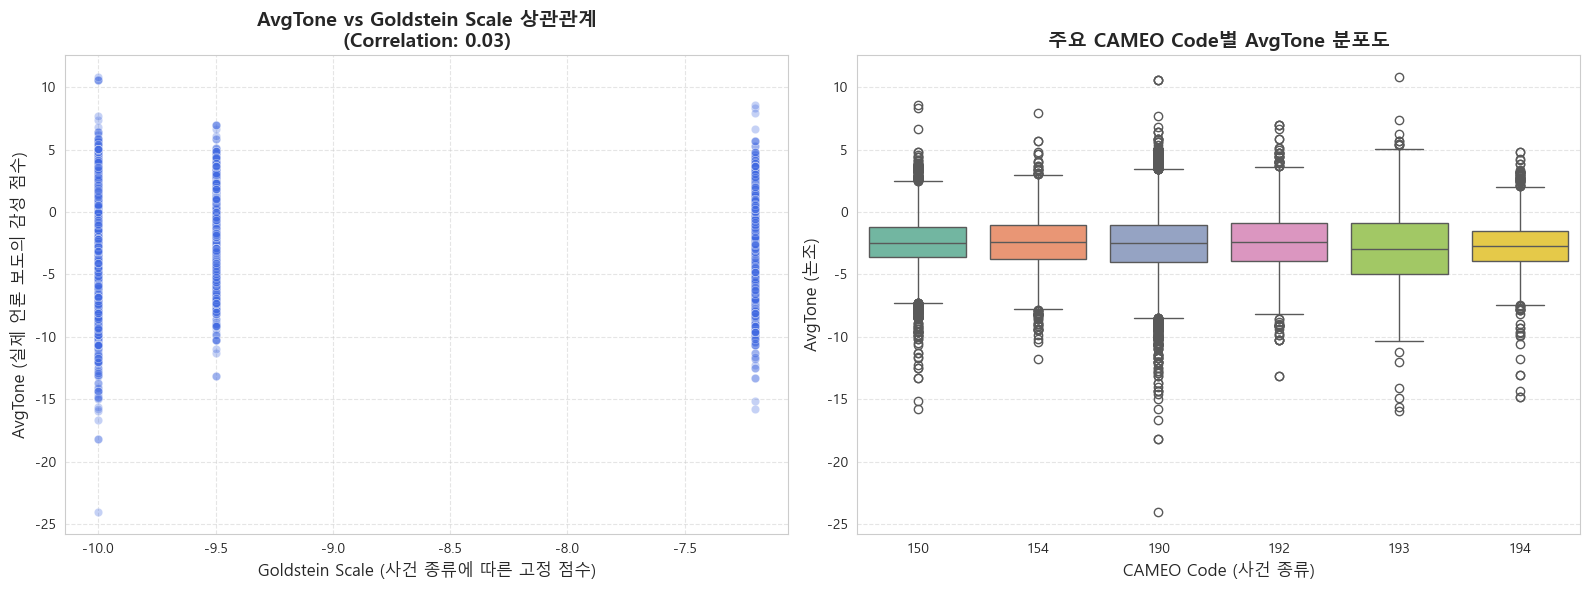

In [124]:
# 1. 상관계수 계산
correlation = df['AvgTone'].corr(df['GoldsteinScale'])
print(f"--- 📈 [상관관계 분석] Tone vs Goldstein ---")
print(f"✔️ 두 지표 간의 피어슨 상관계수: {correlation:.3f}")
print("   (0에 가까울수록 서로 연관성이 없으며, 1 또는 -1에 가까울수록 강한 연관성)\n")

# 2. 화면 분할 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- [그래프 1] AvgTone vs Goldstein Scale 산점도 ---
# 점이 겹치는 것을 보기 위해 alpha 값 조절 및 jitter(떨림) 효과 대체용 투명도 적용
sns.scatterplot(data=df, x='GoldsteinScale', y='AvgTone', alpha=0.3, color='royalblue', ax=axes[0])
axes[0].set_title(f'AvgTone vs Goldstein Scale 상관관계\n(Correlation: {correlation:.2f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Goldstein Scale (사건 종류에 따른 고정 점수)', fontsize=12)
axes[0].set_ylabel('AvgTone (실제 언론 보도의 감성 점수)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- [그래프 2] 주요 CAMEO Code별 AvgTone 분포도 (Boxplot) ---
# 기사량이 가장 많은 상위 6개 CAMEO 코드만 추출하여 시각화
top_cameos = df['EventCode'].value_counts().head(6).index
df_top_cameos = df[df['EventCode'].isin(top_cameos)]

# 범주형 데이터의 순서를 맞춰주기 위해 정렬
order_cameos = sorted(top_cameos)

sns.boxplot(data=df_top_cameos, x='EventCode', y='AvgTone', order=order_cameos, palette='Set2', ax=axes[1])
axes[1].set_title('주요 CAMEO Code별 AvgTone 분포도', fontsize=14, fontweight='bold')
axes[1].set_xlabel('CAMEO Code (사건 종류)', fontsize=12)
axes[1].set_ylabel('AvgTone (논조)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

--- 📊 [기사량 통합 통계] ---
count        2414.0
mean      65.547639
std      217.945841
min             1.0
25%             8.0
50%            15.0
75%            38.0
max          4595.0
Name: NumMentions, dtype: Float64


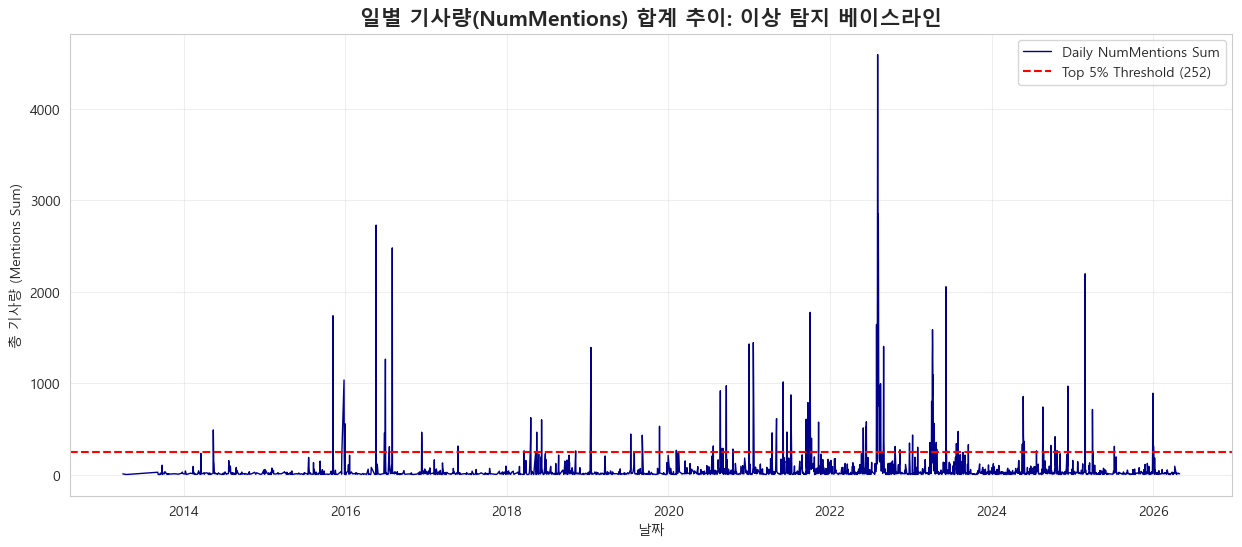


--- 🚨 [기사량 폭발 TOP 10 날짜] ---
        SQLDATE  NumMentions   AvgTone
1519 2022-08-04         4595 -2.999587
1522 2022-08-07         2849 -3.632177
352  2016-05-20         2729  0.433569
384  2016-08-01         2480 -1.787786
1520 2022-08-05         2283 -3.177310
2169 2025-02-27         2197 -3.534473
1751 2023-06-09         2055  0.444163
1523 2022-08-08         2033 -2.993009
1518 2022-08-03         1988 -2.832098
1304 2021-10-03         1775 -3.558631


In [125]:
# 1. 일단위 NumMentions 합계 및 AvgTone 평균 계산
daily_stats = df_filtered.groupby('SQLDATE').agg({
    'NumMentions': 'sum',
    'AvgTone': 'mean',
    'EventCode': 'count' # 사건 건수도 함께 확인
}).reset_index()

# 2. 기초 통계량 확인
print("--- 📊 [기사량 통합 통계] ---")
print(daily_stats['NumMentions'].describe())

# 3. 시계열 시각화
plt.figure(figsize=(15, 6))
plt.plot(daily_stats['SQLDATE'], daily_stats['NumMentions'], color='darkblue', linewidth=1, label='Daily NumMentions Sum')

# 임계값(Threshold) 시각화 (상위 5% 지점)
threshold_val = daily_stats['NumMentions'].quantile(0.95)
plt.axhline(threshold_val, color='red', linestyle='--', label=f'Top 5% Threshold ({threshold_val:.0f})')

plt.title('일별 기사량(NumMentions) 합계 추이: 이상 탐지 베이스라인', fontsize=15, fontweight='bold')
plt.xlabel('날짜')
plt.ylabel('총 기사량 (Mentions Sum)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. 가장 기사량이 폭발했던 Top 10 날짜 추출
top_spikes = daily_stats.sort_values(by='NumMentions', ascending=False).head(10)
print("\n--- 🚨 [기사량 폭발 TOP 10 날짜] ---")
print(top_spikes[['SQLDATE', 'NumMentions', 'AvgTone']])

2022년 8월 낸시 펠로시 의장 방문 및 대규모 무력시위
2022-08-04 (기사량: 4,595 / 논조: -3.00): 중국이 대만 주변 6개 구역에 미사일을 발사
2022-08-05 ~ 08 (기사량: 2,000~2,800 / 논조: -3.63까지 하락): 무력시위가 장기화

2021년 10월 역대 최대 규모의 ADIZ 침범
2021-10-03 (기사량: 1,775 / 논조: -3.56): 중국 국경절 연휴 동안 기록적인 수의 군용기가 대만 방공식별구역(ADIZ)에 진입

2016년 대만 정권 교체 및 정치적 변곡점
2016-05-20 (기사량: 2,729 / 논조: +0.43): 차이잉원 총통의 첫 취임식 날

'취임'이라는 축제 성격의 키워드가 섞여 편향이 발생. 하지만 기사량이 폭발했다는 것은 향후 중-대만 관계의 거대한 변화(리스크)를 암시하는 신호

2016-08-01 (기사량: 2,480 / 논조: -1.79):
중국 인민해방군 건군 기념일(8.1)을 맞아 대규모 해상 훈련이 진행된 날. 취임 후 첫 무력 압박이 본격화된 시점

최근의 긴장 상태 (2023년 ~ 2025년)
2025-02-27 (기사량: 2,197 / 논조: -3.53):
작년 초에 발생했던 대형 군사적 충돌 징후나 해상 봉쇄 훈련으로 추정

2023-06-09 (기사량: 2,055 / 논조: +0.44):
미국과 연합군의 대만 해협 통과나 긍정적인 안보 협력 보도가 많았던 날로 추정

In [126]:
# 1. daily_stats 재정의 (GoldsteinScale 포함)
daily_stats = df_filtered.groupby('SQLDATE').agg({
    'NumMentions': 'sum',
    'AvgTone': 'mean',
    'GoldsteinScale': 'mean', # <-- 이 부분이 추가되어야 합니다!
    'EventCode': 'count'
}).reset_index()

# 2. 확인하고 싶은 주요 스파이크 날짜 리스트
spike_dates = pd.to_datetime([
    '2022-08-04', '2022-08-07', '2016-05-20', '2016-08-01', '2022-08-05', 
    '2025-02-27', '2023-06-09', '2022-08-08', '2022-08-03', '2021-10-03'
])

# 3. 해당 날짜들의 Goldstein 수치 확인
goldstein_check = daily_stats[daily_stats['SQLDATE'].isin(spike_dates)]

print("--- ⚖️ [검증] 주요 사건 발생일의 Goldstein Scale 일관성 확인 ---")
# 소수점 둘째자리까지 출력
print(goldstein_check[['SQLDATE', 'NumMentions', 'GoldsteinScale', 'AvgTone']].sort_values('NumMentions', ascending=False).to_string(index=False, float_format='%.2f'))

--- ⚖️ [검증] 주요 사건 발생일의 Goldstein Scale 일관성 확인 ---
   SQLDATE  NumMentions  GoldsteinScale  AvgTone
2022-08-04         4595           -8.65    -3.00
2022-08-07         2849           -8.36    -3.63
2016-05-20         2729           -9.20     0.43
2016-08-01         2480          -10.00    -1.79
2022-08-05         2283           -8.85    -3.18
2025-02-27         2197           -9.32    -3.53
2023-06-09         2055           -9.76     0.44
2022-08-08         2033           -8.21    -2.99
2022-08-03         1988           -8.67    -2.83
2021-10-03         1775           -8.92    -3.56


--- 🚨 Volume Spike 탐지 결과 (Threshold: 2.5) ---
전체 기간 중 총 107번의 기사량 폭발이 감지되었습니다.


,SQLDATE,NumMentions,Vol_ZScore,AvgTone,GoldsteinScale
1519,2022-08-04,4595,4.59453,-2.999587,-8.649673
352,2016-05-20,2729,5.284351,0.433569,-9.200000
384,2016-08-01,2480,4.626807,-1.787786,-10.000000
2169,2025-02-27,2197,5.254456,-3.534473,-9.325000
1751,2023-06-09,2055,5.241855,0.444163,-9.761111
1518,2022-08-03,1988,3.899157,-2.832098,-8.671831
1304,2021-10-03,1775,4.514023,-3.558631,-8.917647
286,2015-11-07,1738,5.288974,-1.086803,-9.325000
1514,2022-07-30,1642,5.230355,-2.930933,-7.529412
1694,2023-04-09,1585,3.731975,-2.074135,-8.755422


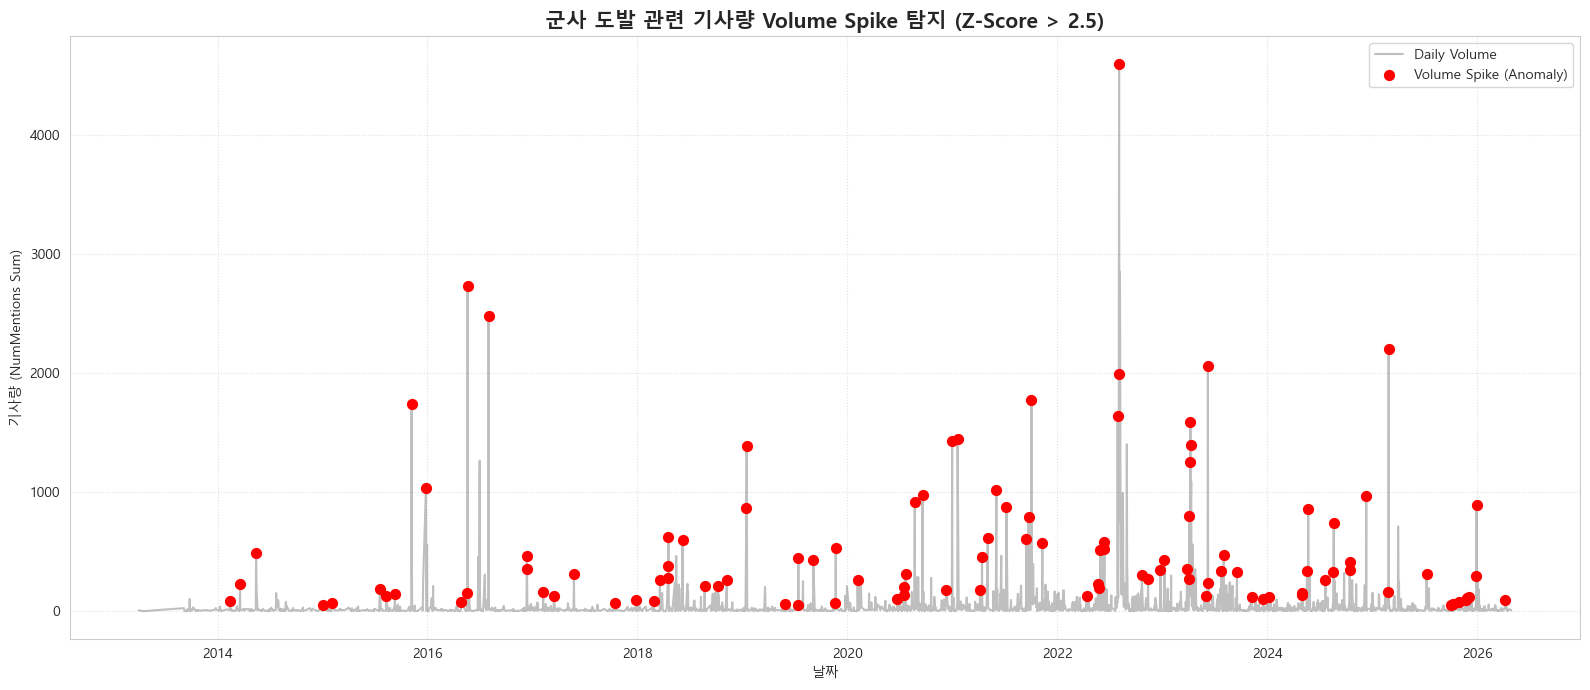

In [ ]:
# 1. Z-Score 기반 Volume Spike 계산
# 윈도우(30일)를 설정하여 최근 흐름 대비 급증한 날 찾기
window = 30
daily_stats['Vol_Mean'] = daily_stats['NumMentions'].rolling(window=window).mean()
daily_stats['Vol_Std'] = daily_stats['NumMentions'].rolling(window=window).std()

# Z-Score = (현재값 - 평균) / 표준편차
daily_stats['Vol_ZScore'] = (daily_stats['NumMentions'] - daily_stats['Vol_Mean']) / daily_stats['Vol_Std']

# 2. 임계값(Threshold) 설정 (보통 2.0 이상이면 '이상치', 3.0 이상이면 '강력한 이상치')
threshold = 2.5
daily_stats['Is_Spike'] = daily_stats['Vol_ZScore'] > threshold

# 3. Spike 발생 날짜만 추출
spikes = daily_stats[daily_stats['Is_Spike'] == True]

print(f"--- 🚨 Volume Spike 탐지 결과 (Threshold: {threshold}) ---")
print(f"전체 기간 중 총 {len(spikes)}번의 기사량 폭발이 감지되었습니다.")
display(spikes[['SQLDATE', 'NumMentions', 'Vol_ZScore', 'AvgTone', 'GoldsteinScale']].sort_values('NumMentions', ascending=False).head(10))

# 4. 시각화
plt.figure(figsize=(16, 7))

# 기사량 전체 추이
plt.plot(daily_stats['SQLDATE'], daily_stats['NumMentions'], color='gray', alpha=0.5, label='Daily Volume')

# Spike 지점 강조
plt.scatter(spikes['SQLDATE'], spikes['NumMentions'], color='red', s=50, label='Volume Spike (Anomaly)', zorder=5)

plt.title(f'군사 도발 관련 기사량 Volume Spike 탐지 (Z-Score > {threshold})', fontsize=15, fontweight='bold')
plt.xlabel('날짜')
plt.ylabel('기사량 (NumMentions Sum)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

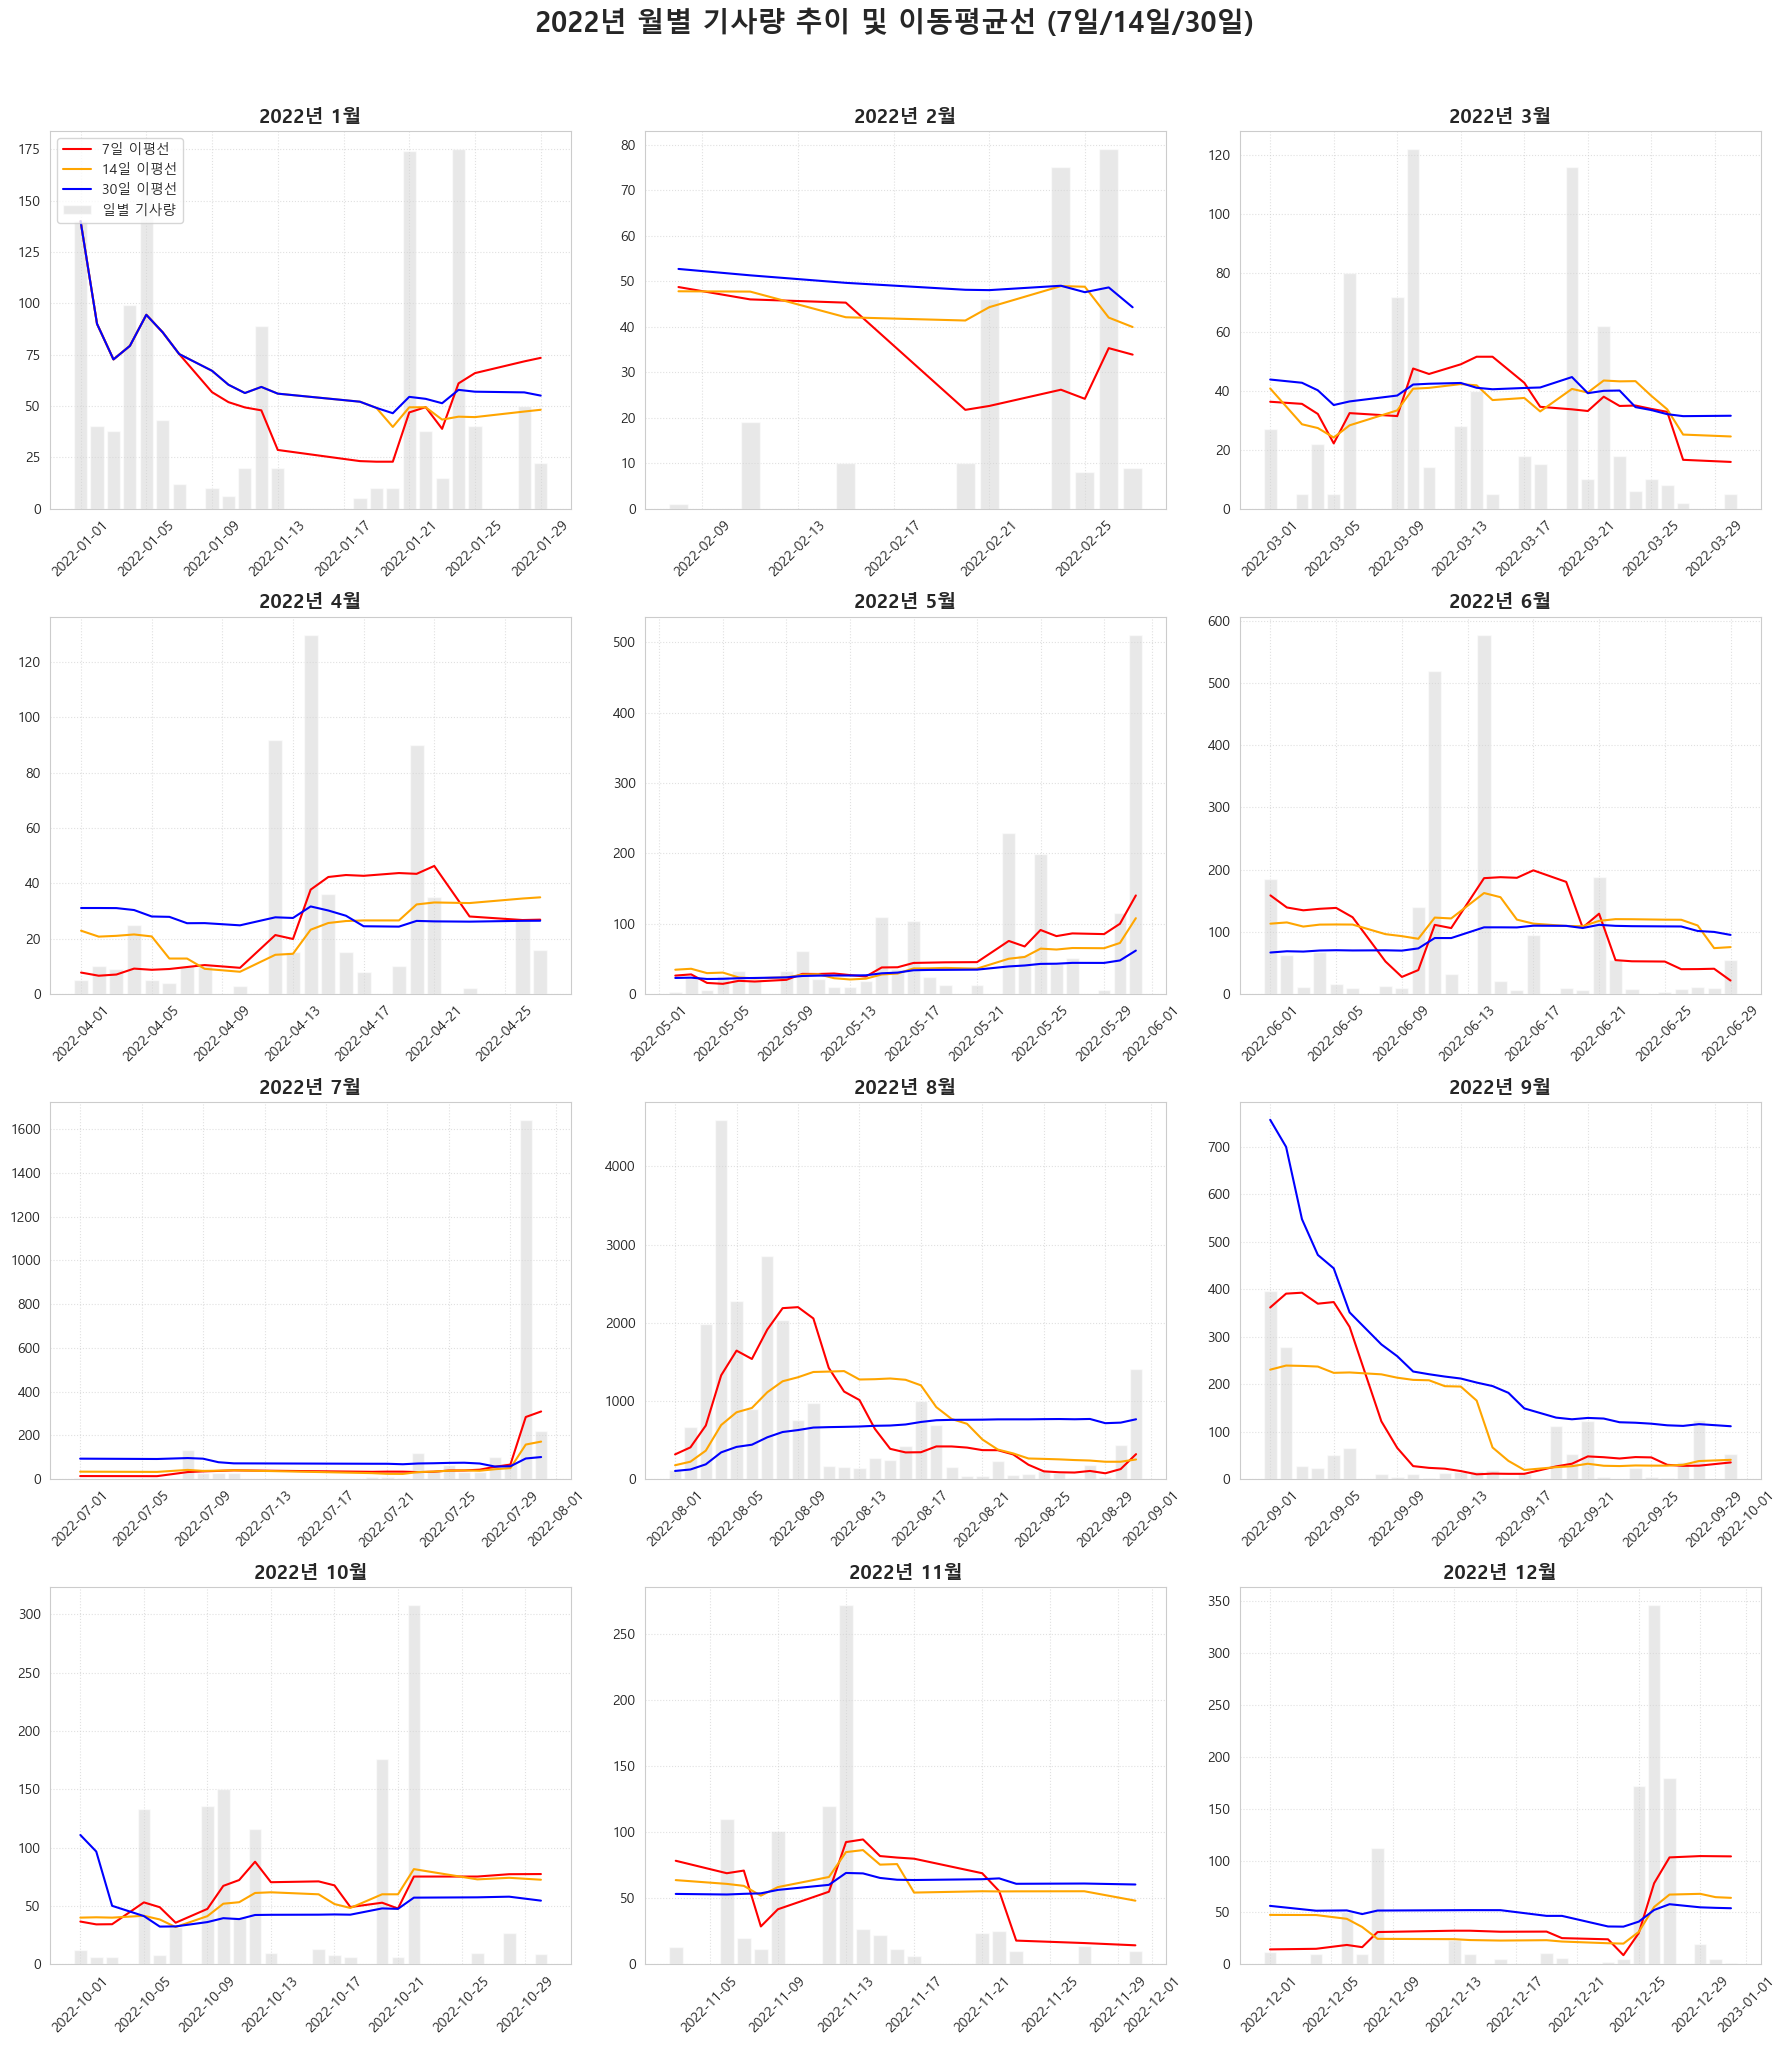

In [129]:
# 1. 한글 폰트 및 마이너스 깨짐 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 2022년 데이터 추출 및 이동평균 계산
df_2022 = daily_stats[(daily_stats['SQLDATE'].dt.year == 2022)].copy()
df_2022 = df_2022.sort_values('SQLDATE')

# 각 이동평균선 계산
df_2022['MA7'] = df_2022['NumMentions'].rolling(window=7, min_periods=1).mean()
df_2022['MA14'] = df_2022['NumMentions'].rolling(window=14, min_periods=1).mean()
df_2022['MA30'] = df_2022['NumMentions'].rolling(window=30, min_periods=1).mean()

# 3. 월별 시각화 (4행 3열 구조)
fig, axes = plt.subplots(4, 3, figsize=(18, 20), sharey=False)
fig.suptitle('2022년 월별 기사량 추이 및 이동평균선 (7일/14일/30일)', fontsize=20, fontweight='bold', y=1.02)

months = range(1, 13)
axes_flat = axes.flatten()

for i, month in enumerate(months):
    ax = axes_flat[i]
    month_data = df_2022[df_2022['SQLDATE'].dt.month == month]
    
    if not month_data.empty:
        # 일별 기사량 (막대)
        ax.bar(month_data['SQLDATE'], month_data['NumMentions'], color='lightgray', alpha=0.5, label='일별 기사량')
        
        # 이동평균선 (선)
        ax.plot(month_data['SQLDATE'], month_data['MA7'], color='red', linewidth=1.5, label='7일 이평선')
        ax.plot(month_data['SQLDATE'], month_data['MA14'], color='orange', linewidth=1.5, label='14일 이평선')
        ax.plot(month_data['SQLDATE'], month_data['MA30'], color='blue', linewidth=1.5, label='30일 이평선')
        
        ax.set_title(f'2022년 {month}월', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        
        # 8월(펠로시 방문) 등 특정 시점 강조를 위해 Y축 범위를 자동 조정
        ax.grid(True, linestyle=':', alpha=0.6)

# 범례 설정 (첫 번째 서브플롯 기준)
axes[0, 0].legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

--- 📍 [이동평균선 돌파 일수 요약] ---


,기준선 (Baseline),돌파 일수 (Days)
0,7일선 초과 (단기),787
1,15일선 초과 (중기),690
2,30일선 초과 (장기),610


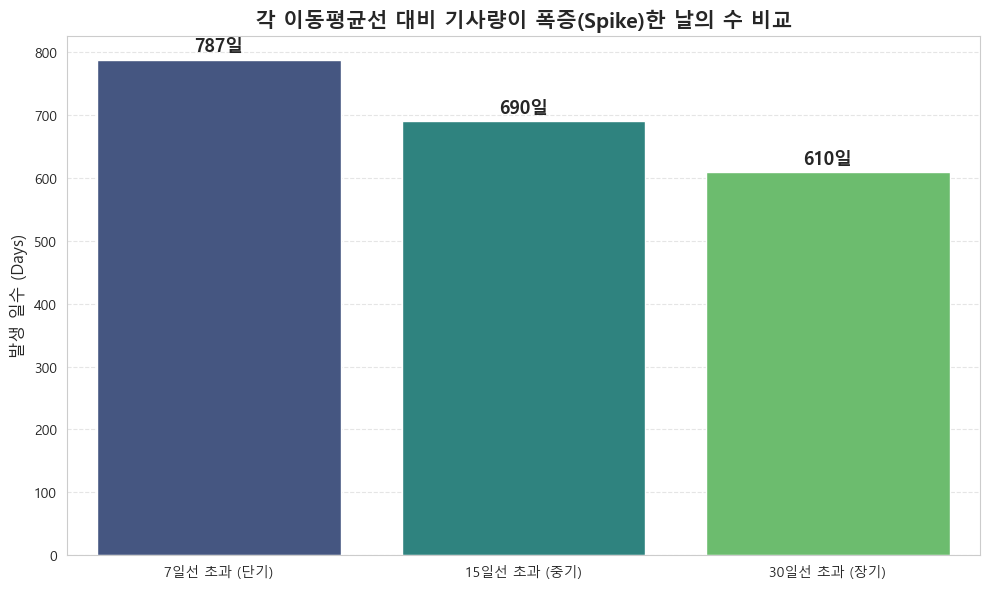

In [132]:
# 1. 한글 폰트 및 설정 (Windows 환경)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 이동평균선 재계산 (daily_stats 기준)
# 이전 단계에서 계산된 값이 있더라도 명확성을 위해 다시 정의합니다.
daily_stats['MA_7'] = daily_stats['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_stats['MA_15'] = daily_stats['NumMentions'].rolling(window=15, min_periods=1).mean()
daily_stats['MA_30'] = daily_stats['NumMentions'].rolling(window=30, min_periods=1).mean()

# 3. 각 이동평균선을 당일 기사량이 초과한 날(True)의 개수 계산
spike_7d = (daily_stats['NumMentions'] > daily_stats['MA_7']).sum()
spike_15d = (daily_stats['NumMentions'] > daily_stats['MA_15']).sum()
spike_30d = (daily_stats['NumMentions'] > daily_stats['MA_30']).sum()

# 4. 데이터프레임 정리
spike_counts = pd.DataFrame({
    '기준선 (Baseline)': ['7일선 초과 (단기)', '15일선 초과 (중기)', '30일선 초과 (장기)'],
    '돌파 일수 (Days)': [spike_7d, spike_15d, spike_30d]
})

print("--- 📍 [이동평균선 돌파 일수 요약] ---")
display(spike_counts)

# 5. 시각화 (요청하신 막대 그래프 형태)
plt.figure(figsize=(10, 6))

# 최신 Seaborn 문법 적용 (hue 지정으로 경고 해결 및 범례 제거)
sns.barplot(
    data=spike_counts, 
    x='기준선 (Baseline)', 
    y='돌파 일수 (Days)', 
    hue='기준선 (Baseline)', 
    palette='viridis', 
    legend=False
)

plt.title('각 이동평균선 대비 기사량이 폭증(Spike)한 날의 수 비교', fontsize=15, fontweight='bold')
plt.ylabel('발생 일수 (Days)', fontsize=12)
plt.xlabel('')

# 막대 위에 실제 수치(일수) 텍스트 추가
for index, value in enumerate(spike_counts['돌파 일수 (Days)']):
    plt.text(index, value + (value * 0.01), f'{value}일', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [135]:
# 1. 일자별(SQLDATE) + 사건코드(EventCode)별 기사 건수 및 언급량 합계 집계
# df_filtered는 앞서 필터링한 1.1만 건의 정제된 데이터셋입니다.
daily_cameo_stats = df_filtered.groupby(['SQLDATE', 'EventCode']).agg({
    'NumMentions': ['count', 'sum'] # count는 해당 코드의 사건 발생 횟수, sum은 총 언급량
}).reset_index()

# 컬럼명 정리
daily_cameo_stats.columns = ['날짜', 'CAMEO코드', '사건건수', '총언급량']

# 2. 분석관님이 확인하기 가장 좋은 '피크 시점' 예시 출력 (예: 2022-08-04)
# 특정 날짜를 지정해서 보고 싶으시다면 아래 query를 수정하세요.
target_date = '2022-08-04'
day_detail = daily_cameo_stats[daily_cameo_stats['날짜'] == target_date].sort_values(by='총언급량', ascending=False)

print(f"--- 📅 [{target_date}] 일일 CAMEO 코드 발생 현황 ---")
print(f"이날 발생한 고유 코드 종류: {len(day_detail)}개")
display(day_detail.head(10)) # 상위 10개 코드 출력

# 3. 전체 기간 동안 하루 평균 몇 개의 코드가 생성되는지 통계 확인
avg_codes_per_day = daily_cameo_stats.groupby('날짜')['CAMEO코드'].count().mean()
print(f"\n💡 분석 기간 내 하루 평균 발생 코드 종류: {avg_codes_per_day:.1f}개")

--- 📅 [2022-08-04] 일일 CAMEO 코드 발생 현황 ---
이날 발생한 고유 코드 종류: 9개


,날짜,CAMEO코드,사건건수,총언급량
2422,2022-08-04,194,52,2859
2415,2022-08-04,150,57,1380
2419,2022-08-04,191,6,105
2418,2022-08-04,190,10,70
2417,2022-08-04,154,9,65
2420,2022-08-04,192,4,35
2416,2022-08-04,151,6,33
2421,2022-08-04,193,5,28
2423,2022-08-04,195,4,20



💡 분석 기간 내 하루 평균 발생 코드 종류: 1.7개


In [147]:
# 1. 확인하고 싶은 날짜 설정
target_date = '2022-08-04'

# 2. 해당 날짜의 코드별 고유 좌표(Lat, Long) 개수 확인
geo_check = df_filtered[df_filtered['SQLDATE'] == target_date].groupby('EventCode').agg({
    'ActionGeo_Lat': ['nunique', 'mean'], # 좌표가 몇 종류나 되는지, 평균 위치는 어디인지
    'ActionGeo_Long': ['nunique', 'mean'],
    'NumMentions': 'sum'
}).reset_index()

# 컬럼명 정리
geo_check.columns = ['EventCode', '고유위도수', '평균위도', '고유경도수', '평균경도', '총언급량']

print(f"--- 📍 [{target_date}] 코드별 지리적 분포 요약 ---")
display(geo_check.sort_values(by='총언급량', ascending=False))

--- 📍 [2022-08-04] 코드별 지리적 분포 요약 ---


,EventCode,고유위도수,평균위도,고유경도수,평균경도,총언급량
7,194,18,31.971798,18,111.443206,2859
0,150,16,30.075353,17,104.195060,1380
4,191,4,35.724750,4,54.203383,105
3,190,5,29.391200,5,119.271000,70
2,154,8,30.474367,8,119.882000,65
5,192,1,24.000000,2,120.000000,35
1,151,4,31.969117,4,54.063200,33
6,193,3,31.414260,4,114.569600,28
8,195,2,24.109175,2,118.829500,20


In [148]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd

# 1. 2022년 8월 4일 데이터만 추출 (좌표가 있는 데이터만)
target_date = '2022-08-04'
map_data = df_filtered[
    (df_filtered['SQLDATE'] == target_date) & 
    (df_filtered['ActionGeo_Lat'].notnull()) & 
    (df_filtered['ActionGeo_Long'].notnull())
].copy()

# 2. 지도 초기화 (대만 인근 중심 좌표)
m = folium.Map(location=[23.5, 121.0], zoom_start=6, tiles='CartoDB positron')

# 3. 코드별 색상 지정 (주요 도발 코드는 붉은색 계열)
color_map = {
    '194': 'red',     # 미사일/포격 (가장 위험)
    '150': 'orange',  # 군사 시위
    '190': 'darkred', # 무력 사용
    '154': 'purple',  # 병력 이동
    '151': 'blue'     # 경계 태세
}

# 4. 지도에 좌표 찍기
for _, row in map_data.iterrows():
    code = str(row['EventCode'])
    color = color_map.get(code, 'gray') # 정의되지 않은 코드는 회색
    
    folium.CircleMarker(
        location=[row['ActionGeo_Lat'], row['ActionGeo_Long']],
        radius=row['NumMentions'] / 50 + 3, # 언급량이 많을수록 점의 크기를 키움
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f"코드: {code}<br>언급량: {row['NumMentions']}<br>논조: {row['AvgTone']}"
    ).add_to(m)

# 5. 지도 저장 및 확인
m.save('incident_map_20220804.html')
m

### GDELT 데이터의 좌표는 어떻게 지정되는가?
GDELT의 지리 정보(ActionGeo)는 수동 입력이 아닌 AI 기반의 자동 추출 프로세스를 통해 생성

1. 개체명 인식 (NER: Named Entity Recognition):

기사 텍스트 내에서 도시명, 주 이름, 랜드마크, 위도/경도 표기 등을 모두 찾아냅니다.

2. 지명 매칭 (Geocoding):

추출된 지명을 전 세계 지명 사전(GeoNames 등)과 대조합니다. 예를 들어 기사에 "Keelung Port"라는 단어가 나오면, 사전의 해당 위경도 값인 (25.13, 121.74)를 가져옵니다.

3. 사건 중심지 판별 (Disambiguation):

한 기사에 여러 지명이 나올 경우, 문맥상 "이 사건이 실제 발생한 핵심 장소"가 어디인지 판단하여 ActionGeo 컬럼에 할당합니다.

4. 좌표의 정밀도 (GeoType):

GDELT는 좌표의 성격을 함께 제공합니다.

Type 1: 국가 단위 (정밀도 낮음)

Type 2: 주/도 단위

Type 3: 도시/마을 단위

Type 4: 아주 구체적인 지점 (정밀도 높음)

In [150]:
# 1. 대상 날짜 데이터 필터링 (2022-08-04)
target_date = '2022-08-04'
day_data = df_filtered[df_filtered['SQLDATE'] == target_date]

# 2. 좌표별(위도/경도) 기사 언급량(NumMentions) 합계 집계
top_locations = day_data.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg({
    'NumMentions': 'sum',           # 언급량 총합
    'EventCode': 'nunique',         # 해당 지점에서 발생한 사건 종류 수
    'AvgTone': 'mean'               # 해당 지점 보도들의 평균 논조
}).reset_index()

# 3. 언급량 기준 내림차순 정렬 및 상위 5개 추출
top_5_spots = top_locations.sort_values(by='NumMentions', ascending=False).head(5)

# 4. 결과 출력
print(f"--- 🎯 [{target_date}] 위성 촬영 우선순위 Top 5 좌표 ---")
display(top_5_spots)

--- 🎯 [2022-08-04] 위성 촬영 우선순위 Top 5 좌표 ---


,ActionGeo_Lat,ActionGeo_Long,NumMentions,EventCode,AvgTone
29,39.9289,116.388,1524,7,-3.292932
6,24.0000,119.000,716,7,-3.021569
20,28.7925,117.262,700,1,-4.222615
17,25.0478,121.532,623,5,-2.702902
24,32.9500,116.642,300,1,-4.222615


1. 중국 베이징 (Beijing)
2. 대만 해협 남부 (Taiwan Strait)
3. 중국 장시성 러핑 (Leping, Jiangxi) - 내륙 군사 거점
4. 대만 타이베이 (Taipei)
5. 중국 안후이성 벙부 (Bengbu, Anhui) - 내륙 군사 거점

### AvgTone 수치의 결정적 차이: '말'과 '행동'의 구분

- 정치적 중심지 (베이징/타이베이, Tone -2.7~-3.2): "유감이다", "강력히 규탄한다" 등 외교적 수사가 섞인 보도가 많아 논조가 아주 극단적으로 내려가지는 않음

- 군사 거점 (내륙 기지, Tone -4.22): 이곳에서 나오는 보도는 "미사일 발사", "실탄 사격", "최고 경계 태세" 등 물리적 위협이 직설적으로 묘사. 감정 섞인 단어의 비중이 훨씬 높기 때문에 수치가 급락

In [146]:
import pandas as pd
from IPython.display import HTML

# 1. Pandas 출력 옵션 설정 (데이터프레임 출력 시 URL 생략 방지)
pd.set_option('display.max_colwidth', None)

# 2. 확인하고 싶은 타겟 설정
# 분석관님이 궁금하신 날짜와 코드로 수정 가능합니다.
target_date = '2022-08-04'
target_code = '150'

# 3. 데이터 필터링 및 변수 정의 (NameError 방지)
url_full_view = df_filtered[
    (df_filtered['SQLDATE'] == target_date) & 
    (df_filtered['EventCode'] == target_code)
].sort_values(by='NumMentions', ascending=False).head(15)

# 4. 클릭 가능한 링크로 변환하는 함수
def make_clickable(val):
    return f'<a target="_blank" href="{val}">{val}</a>'

# 5. 최종 결과 출력 (HTML 렌더링)
print(f"--- 🌐 [{target_date}] 코드 [{target_code}] 주요 기사 리스트 (클릭 가능) ---")

if not url_full_view.empty:
    display(HTML(url_full_view[['NumMentions', 'AvgTone', 'SOURCEURL']].to_html(
        render_links=True, 
        escape=False, 
        formatters={'SOURCEURL': make_clickable}
    )))
else:
    print("해당 날짜와 코드에 맞는 데이터가 없습니다. 필터링 조건을 확인해주세요.")

--- 🌐 [2022-08-04] 코드 [150] 주요 기사 리스트 (클릭 가능) ---


,NumMentions,AvgTone,SOURCEURL
6331,378,-2.070194,https://www.stuff.co.nz/world/asia/300654066/china-tightens-noose-with-taiwan-blockade
6315,130,-2.139968,https://inlandnewstoday.com/story.php?s=68209
6396,96,-2.530253,https://www.msn.com/en-us/news/world/facing-growing-threats-from-china-these-big-war-games-are-how-taiwan-prepares-to-fend-off-a-chinese-invasion/ar-AA10igSj
6353,90,-3.815577,https://www.ndtv.com/world-news/chinas-military-drills-after-nancy-pelosi-visit-irresponsible-warns-us-3222946
6327,68,-3.514357,https://www.nytimes.com/2022/08/03/world/asia/taiwan-china-military-exercises.html
6432,62,-3.850851,https://www.thestar.com.my/aseanplus/aseanplus-news/2022/08/04/china-begins-major-taiwan-military-drills-after-pelosi-visit
6319,56,-0.929871,https://www.wvnews.com/mineralnews/newsfeed/world/pelosi-tells-taiwan-us-commitment-to-democracy-is-ironclad/article_7857b3c1-7aa7-5724-89e5-bb14c5098169.html
6407,39,-0.916401,https://www.wvnews.com/mineralnews/newsfeed/world/pelosi-tells-taiwan-us-commitment-to-democracy-is-ironclad/article_7857b3c1-7aa7-5724-89e5-bb14c5098169.html
6308,38,-4.115575,https://economictimes.indiatimes.com/news/defence/china-to-stage-major-drills-around-taiwan-after-pelosi-visit/articleshow/93336123.cms
6383,34,-2.869570,https://apnews.com/article/taiwan-technology-health-asia-china-4e66d6d2944204a5261b4bfbe0048688


In [149]:
# 1. 일자별(SQLDATE) + 사건코드(EventCode)별 기사 건수 및 언급량 합계 집계
# df_filtered는 앞서 필터링한 1.1만 건의 정제된 데이터셋입니다.
daily_cameo_stats = df_filtered.groupby(['SQLDATE', 'EventCode']).agg({
    'NumMentions': ['count', 'sum'] # count는 해당 코드의 사건 발생 횟수, sum은 총 언급량
}).reset_index()

# 컬럼명 정리
daily_cameo_stats.columns = ['날짜', 'CAMEO코드', '사건건수', '총언급량']

# 2. 분석관님이 확인하기 가장 좋은 '피크 시점' 예시 출력 (예: 2022-08-04)
# 특정 날짜를 지정해서 보고 싶으시다면 아래 query를 수정하세요.
target_date = '2021-10-03'
day_detail = daily_cameo_stats[daily_cameo_stats['날짜'] == target_date].sort_values(by='총언급량', ascending=False)

print(f"--- 📅 [{target_date}] 일일 CAMEO 코드 발생 현황 ---")
print(f"이날 발생한 고유 코드 종류: {len(day_detail)}개")
display(day_detail.head(10)) # 상위 10개 코드 출력

# 3. 전체 기간 동안 하루 평균 몇 개의 코드가 생성되는지 통계 확인
avg_codes_per_day = daily_cameo_stats.groupby('날짜')['CAMEO코드'].count().mean()
print(f"\n💡 분석 기간 내 하루 평균 발생 코드 종류: {avg_codes_per_day:.1f}개")

--- 📅 [2021-10-03] 일일 CAMEO 코드 발생 현황 ---
이날 발생한 고유 코드 종류: 5개


,날짜,CAMEO코드,사건건수,총언급량
1976,2021-10-03,192,12,1598
1973,2021-10-03,151,7,89
1977,2021-10-03,195,6,41
1975,2021-10-03,190,5,35
1974,2021-10-03,154,4,12



💡 분석 기간 내 하루 평균 발생 코드 종류: 1.7개


--- 🔍 [df_filtered] 기준 일일 기사량 통계 ---
count        2414.0
mean      65.547639
std      217.945841
min             1.0
50%            15.0
75%            38.0
90%           126.7
95%          252.35
99%          975.48
max          4595.0
Name: NumMentions, dtype: Float64

--- 🛰️ 임계값 설정별 위성 가동 시뮬레이션 ---
상위 10% 기준 (126건 이상): 연간 약 242일 촬영 발생
상위 5% 기준 (252건 이상): 연간 약 121일 촬영 발생
상위 1% 기준 (975건 이상): 연간 약 25일 촬영 발생


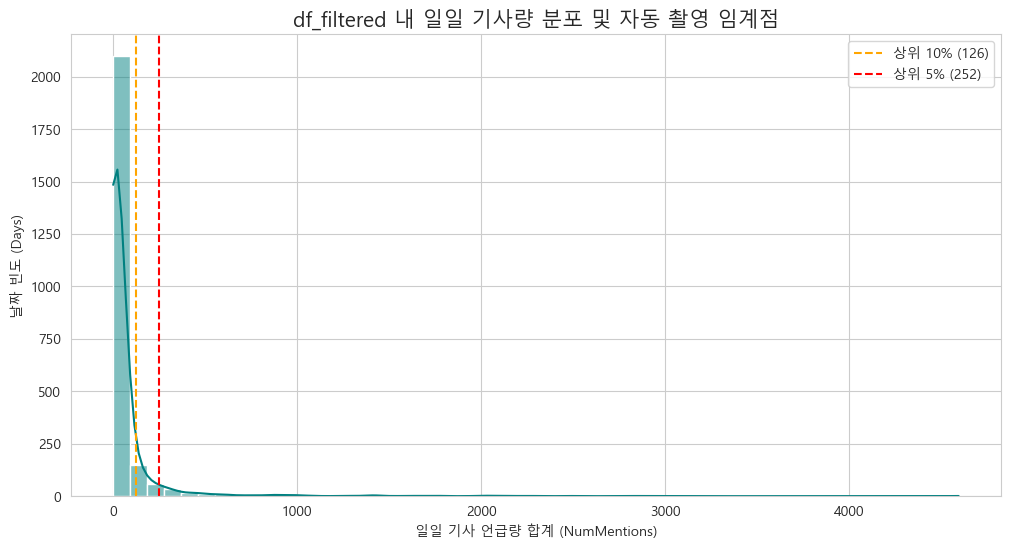

In [152]:
# 1. 기사량 합계
daily_vol_filtered = df_filtered.groupby('SQLDATE')['NumMentions'].sum().reset_index()

# 2. 기초 통계량 및 백분위수(Percentiles) 확인
# 어느 정도 수치가 '상위 5%'에 해당하는지 파악합니다.
stats_filtered = daily_vol_filtered['NumMentions'].describe(percentiles=[.5, .75, .9, .95, .99])

print("--- 🔍 [df_filtered] 기준 일일 기사량 통계 ---")
print(stats_filtered)

# 3. 위성 가동 효율성 시뮬레이션
# 임계값을 어디로 잡느냐에 따라 실제 위성을 움직일 '출동 횟수'가 달라집니다.
target_percentiles = [('상위 10%', stats_filtered['90%']), 
                      ('상위 5%', stats_filtered['95%']), 
                      ('상위 1%', stats_filtered['99%'])]

print("\n--- 🛰️ 임계값 설정별 위성 가동 시뮬레이션 ---")
for label, val in target_percentiles:
    active_days = (daily_vol_filtered['NumMentions'] >= val).sum()
    print(f"{label} 기준 ({int(val)}건 이상): 연간 약 {active_days}일 촬영 발생")

# 4. 시각화 (임계선 표시)
plt.figure(figsize=(12, 6))
sns.histplot(daily_vol_filtered['NumMentions'], bins=50, kde=True, color='teal')

plt.axvline(stats_filtered['90%'], color='orange', linestyle='--', label=f'상위 10% ({int(stats_filtered["90%"])})')
plt.axvline(stats_filtered['95%'], color='red', linestyle='--', label=f'상위 5% ({int(stats_filtered["95%"])})')

plt.title('df_filtered 내 일일 기사량 분포 및 자동 촬영 임계점', fontsize=15)
plt.xlabel('일일 기사 언급량 합계 (NumMentions)')
plt.ylabel('날짜 빈도 (Days)')
plt.legend()
plt.show()

--- 🚀 [df_filtered] 기사량 증가율 통계 ---
count         2414.0
mean      331.677868
std      1611.894846
min       -99.561404
50%              0.0
75%            170.0
90%            700.0
95%           1400.0
99%           6973.3
max          30200.0
Name: GrowthRate, dtype: Float64


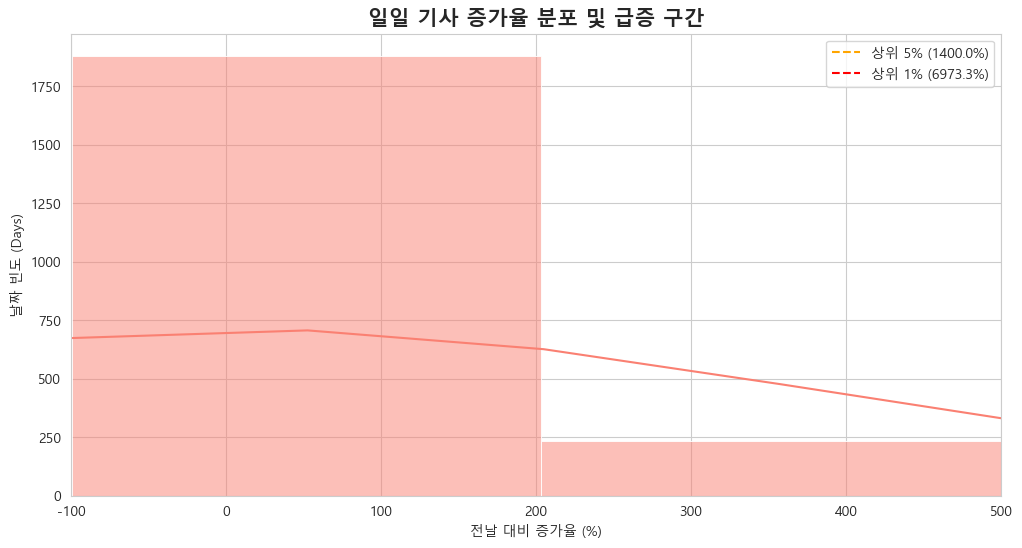


--- 🔥 역대급 기사 폭증일 (Growth Rate 상위 1%) ---


,SQLDATE,NumMentions,GrowthRate
1288,2021-09-15,606,30200.0
1251,2021-07-08,872,28966.666667
1793,2023-08-03,473,23550.0
873,2019-09-05,431,21450.0
384,2016-08-01,2480,20566.666667
379,2016-07-19,307,15250.0
1063,2020-09-18,555,13775.0
938,2020-02-06,266,13200.0
919,2019-12-25,130,12900.0
737,2018-11-08,259,12850.0


In [154]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. df_filtered 데이터를 날짜별로 집계 및 정렬
daily_vol = df_filtered.groupby('SQLDATE')['NumMentions'].sum().reset_index().sort_values('SQLDATE')

# 2. 전날 대비 증가율(%) 계산
daily_vol['GrowthRate'] = daily_vol['NumMentions'].pct_change() * 100

# 3.무한대(inf) 및 결측치 처리
daily_vol['GrowthRate'] = daily_vol['GrowthRate'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 4. 증가율 백분위수(Percentiles) 산출
growth_stats = daily_vol['GrowthRate'].describe(percentiles=[.5, .75, .9, .95, .99])

print("--- 🚀 [df_filtered] 기사량 증가율 통계 ---")
print(growth_stats)

# 5. 시각화: 증가율 분포와 임계점 확인
plt.figure(figsize=(12, 6))
sns.histplot(daily_vol['GrowthRate'], bins=100, kde=True, color='salmon')

# 상위 5% 및 1% 증가율 지점 표시
plt.axvline(growth_stats['95%'], color='orange', linestyle='--', label=f'상위 5% ({growth_stats["95%"]:.1f}%)')
plt.axvline(growth_stats['99%'], color='red', linestyle='--', label=f'상위 1% ({growth_stats["99%"]:.1f}%)')

plt.title('일일 기사 증가율 분포 및 급증 구간', fontsize=15, fontweight='bold')
plt.xlabel('전날 대비 증가율 (%)')
plt.ylabel('날짜 빈도 (Days)')
plt.xlim(-100, 500) # 가독성을 위해 극단적 수치 범위 제한
plt.legend()
plt.show()

# 6. 상위 1% 폭증일 리스트 추출
top_growth_days = daily_vol[daily_vol['GrowthRate'] >= growth_stats['99%']].sort_values(by='GrowthRate', ascending=False)
print("\n--- 🔥 역대급 기사 폭증일 (Growth Rate 상위 1%) ---")
display(top_growth_days.head(10))

In [155]:
# 어제 기사수를 포함하여 다시 확인
daily_vol['Yesterday_Mentions'] = daily_vol['NumMentions'].shift(1)

# 오늘 기사가 100건 이상이면서, 증가율이 높은 날만 필터링 (의미 있는 날)
real_spikes = daily_vol[
    (daily_vol['NumMentions'] >= 100) & 
    (daily_vol['GrowthRate'] > 0)
].sort_values(by='GrowthRate', ascending=False)

print("--- 🛡️ 노이즈를 제거한 실질적 폭증일 리스트 ---")
display(real_spikes[['SQLDATE', 'Yesterday_Mentions', 'NumMentions', 'GrowthRate']].head(10))

--- 🛡️ 노이즈를 제거한 실질적 폭증일 리스트 ---


,SQLDATE,Yesterday_Mentions,NumMentions,GrowthRate
1288,2021-09-15,2,606,30200.0
1251,2021-07-08,3,872,28966.666667
1793,2023-08-03,2,473,23550.0
873,2019-09-05,2,431,21450.0
384,2016-08-01,12,2480,20566.666667
379,2016-07-19,2,307,15250.0
1063,2020-09-18,4,555,13775.0
938,2020-02-06,2,266,13200.0
919,2019-12-25,1,130,12900.0
737,2018-11-08,2,259,12850.0


In [156]:
# 1. 각 기준의 임계값(Threshold) 계산
vol_1pct = daily_vol['NumMentions'].quantile(0.99)
growth_1pct = daily_vol['GrowthRate'].quantile(0.99)

# 2. 두 조건을 모두 만족하는 날 추출
critical_days = daily_vol[
    (daily_vol['NumMentions'] >= vol_1pct) & 
    (daily_vol['GrowthRate'] >= growth_1pct)
]

print(f"--- 🚨 [상위 1% & 1%] 필터를 통과한 날짜 리스트 ---")
print(f"조건 만족 일수: 총 {len(critical_days)}일")
display(critical_days.sort_values(by='SQLDATE', ascending=False))

--- 🚨 [상위 1% & 1%] 필터를 통과한 날짜 리스트 ---
조건 만족 일수: 총 3일


,SQLDATE,NumMentions,GrowthRate,Yesterday_Mentions
1129,2020-12-31,1429,8305.882353,17
384,2016-08-01,2480,20566.666667,12
367,2016-07-01,1263,12530.0,10


In [158]:
# 1. 각 기준의 임계값(Threshold) 계산
vol_1pct = daily_vol['NumMentions'].quantile(0.95)
growth_1pct = daily_vol['GrowthRate'].quantile(0.95)

# 2. 두 조건을 모두 만족하는 날 추출
critical_days = daily_vol[
    (daily_vol['NumMentions'] >= vol_1pct) & 
    (daily_vol['GrowthRate'] >= growth_1pct)
]

print(f"--- 🚨 [상위 5% & 5%] 필터를 통과한 날짜 리스트 ---")
print(f"조건 만족 일수: 총 {len(critical_days)}일")
display(critical_days.sort_values(by='SQLDATE', ascending=False))

--- 🚨 [상위 5% & 5%] 필터를 통과한 날짜 리스트 ---
조건 만족 일수: 총 43일


,SQLDATE,NumMentions,GrowthRate,Yesterday_Mentions
2347,2025-12-29,299,1768.75,16
2246,2025-07-09,310,1837.5,16
2192,2025-04-01,713,4992.857143,14
2056,2024-08-23,257,2041.666667,12
2052,2024-08-19,330,1733.333333,18
1980,2024-05-23,855,9400.0,9
1977,2024-05-19,334,3240.0,10
1828,2023-09-18,328,6460.0,5
1793,2023-08-03,473,23550.0,2
1753,2023-06-11,269,2590.0,10


In [160]:
import pandas as pd
import numpy as np

# 1. 임계값(Threshold) 자동 재정의
# 기사량 상위 5%와 증가율 상위 5% 지점의 수치를 변수에 할당합니다.
vol_5pct = daily_vol['NumMentions'].quantile(0.95)
growth_5pct = daily_vol['GrowthRate'].quantile(0.95)

# 2. 기사량은 상위 5%인데, 증가율 조건 때문에 탈락한 날들 (지속되는 위기 상황)
# 어제도 난리였고 오늘도 난리인 경우, 증가율은 낮지만 촬영은 반드시 필요합니다.
missed_by_growth = daily_vol[
    (daily_vol['NumMentions'] >= vol_5pct) & 
    (daily_vol['GrowthRate'] < growth_5pct)
].sort_values(by='NumMentions', ascending=False)

# 3. 추가 분석: 논조(AvgTone)가 최악인 날들 (숨겨진 위험)
# daily_tone 변수가 없다면 생성 후 결합
daily_tone = df_filtered.groupby('SQLDATE')['AvgTone'].mean().reset_index()
merged_check = pd.merge(daily_vol, daily_tone, on='SQLDATE')

missed_by_tone = merged_check[
    (merged_check['NumMentions'] >= daily_vol['NumMentions'].quantile(0.90)) & 
    (merged_check['AvgTone'] <= -5.0) &
    (merged_check['GrowthRate'] < growth_5pct)
]

print(f"--- 📊 현재 기준 임계값: 기사량 {int(vol_5pct)}건 / 증가율 {growth_5pct:.1f}% ---")
print(f"--- ⚠️ '지속적 위기'로 인해 놓쳤던 날들: {len(missed_by_growth)}일 ---")
display(missed_by_growth[['SQLDATE', 'NumMentions', 'GrowthRate']].head(10))

print(f"\n--- 💀 '심각한 논조'로 인해 주목해야 할 날들: {len(missed_by_tone)}일 ---")
display(missed_by_tone[['SQLDATE', 'NumMentions', 'AvgTone', 'GrowthRate']].head(10))

--- 📊 현재 기준 임계값: 기사량 252건 / 증가율 1400.0% ---
--- ⚠️ '지속적 위기'로 인해 놓쳤던 날들: 78일 ---


,SQLDATE,NumMentions,GrowthRate
1519,2022-08-04,4595,131.136821
1522,2022-08-07,2849,217.96875
1520,2022-08-05,2283,-50.31556
2169,2025-02-27,2197,1264.596273
1751,2023-06-09,2055,752.697095
1523,2022-08-08,2033,-28.641629
1518,2022-08-03,1988,200.75643
1304,2021-10-03,1775,285.032538
1694,2023-04-09,1585,26.194268
1546,2022-08-31,1402,225.290023



--- 💀 '심각한 논조'로 인해 주목해야 할 날들: 4일 ---


,SQLDATE,NumMentions,AvgTone,GrowthRate
923,2019-12-31,211,-7.998970,603.333333
1187,2021-04-07,175,-5.401336,548.148148
1482,2022-06-11,520,-5.485394,271.428571
2254,2025-07-17,194,-5.007525,397.435897


In [ ]:
# 1. 30일 이동평균선(MA30) 계산
daily_vol = daily_vol.sort_values('SQLDATE')
daily_vol['MA30'] = daily_vol['NumMentions'].rolling(window=30).mean()

# 2. 임계값(상위 10%) 정의
vol_10pct = daily_vol['NumMentions'].quantile(0.90)
growth_10pct = daily_vol['GrowthRate'].quantile(0.90)

# 3. 3중 교집합 조건 적용
# - 조건 1: 기사 절대량이 상위 10% 이상 (Heavy Volume)
# - 조건 2: 증가율이 상위 10% 이상 (Sudden Spike)
# - 조건 3: 현재 기사량이 30일 평균보다 높음 (Trend Break)
triple_filter_days = daily_vol[
    (daily_vol['NumMentions'] >= vol_10pct) & 
    (daily_vol['GrowthRate'] >= growth_10pct) &
    (daily_vol['NumMentions'] > daily_vol['MA30'])
].dropna() # MA30 계산을 위한 초기 30일 제외

print(f"--- 🛰️ 위성 촬영 '황금 타겟' 추출 결과 ---")
print(f"전체 데이터 중 교집합 일수: 총 {len(triple_filter_days)}일")
display(triple_filter_days[['SQLDATE', 'NumMentions', 'MA30', 'GrowthRate']].head(15))

SyntaxError: invalid syntax (2260742955.py, line 17)